# Week 8 — Basic Portfolio-Weighting Methods

[Open this notebook in Google Colab](https://colab.research.google.com/github/KennethWYLee/FinTech/blob/main/course/08/week8_main.ipynb)

The course repository is public. If the direct Colab link is temporarily unavailable, download `week8_main.ipynb` from GitHub and upload it to Colab.

This is the complete Week 8 lesson. It converts information known before a return interval into target portfolio weights and then compares four baseline rules: equal weighting, market-capitalization weighting, signal-based weighting, and inverse-volatility weighting. Every comparison uses the same assets, return dates, position cap, monthly rebalance schedule, one-period information lag, and Week 6 teaching cost. The signal-based rule uses equal weights only when no positive signal exists or when the assets with positive signals cannot fill 100% of the portfolio under the declared cap; every such event is recorded.

The AAPL, MSFT, JPM, and XOM closing prices and the provider-returned shares series come through yfinance. The selected universe, frozen shares date, momentum definition, volatility window, fallback, position cap, rebalance schedule, and 4-basis-point cost are teaching decisions. Daily closing data do not show tradable quotes, orders, fills, taxes, financing, or an index provider's official constituent and float-adjustment records.

## Core financial question

How do available inputs become feasible portfolio weights, and what can a common-condition historical comparison establish about the four weighting rules?

Run the notebook from top to bottom. Before each code cell, record the requested prediction.


## Observable outcome

After completing Week 8, you will produce feasible target weights, information-date records, holding-weight drift, rebalance and turnover calculations, gross-to-net ledgers, concentration measures, a common-condition performance table, two sensitivity comparisons, and a final audit. Each conclusion will name the method, metric, direction, comparison baseline, evaluation period, and material limitation.

## Learning objectives

After completing Week 8, you should be able to:

- distinguish a trading signal, target portfolio weight, pre-trade holding weight, and post-return holding weight;
- check full-investment, long-only, no-leverage, and individual-position constraints;
- calculate equal, market-capitalization, signal-based, and inverse-volatility weights;
- explain the inputs, units, information time, fallback, and limitations of each rule;
- distinguish a target weight from the holding weight that drifts after asset returns;
- apply a one-period lag, monthly rebalance schedule, one-way turnover, and common transaction cost;
- compare concentration and Week 7 performance measures on identical dates; and
- report cap and lookback sensitivity without selecting a universally best method.

## Before you begin

Complete [Week 7](../07/week7_main.ipynb) or review its return, annualization, drawdown, turnover, cost, benchmark-alignment, and evidence-limit conventions. This notebook requires Python, NumPy, pandas, matplotlib, IPython, yfinance, and network access for a complete top-to-bottom run. If the source request is unavailable, the controlled examples may still be reviewed separately, but the source-grounded cells cannot be executed or verified.


# Navigation through the twenty issues

| Section | Issues | Main question | Evidence carried forward |
|---|---:|---|---|
| Meaning, normalization, and constraints | 1–4 | What is being converted into a weight, and is the result feasible? | Target-weight definitions and constraint checks |
| Four basic weighting rules | 5–8 | Which input determines each method's relative allocation? | Equal, capitalization, signal-based, and inverse-volatility weights |
| Information and implementation | 9–15 | Which dated inputs are available, and how do holdings, turnover, and costs evolve? | Input-date records and gross-to-net rebalance ledgers |
| Comparison and sensitivity | 16–20 | How do concentration, performance, cap, and lookback results differ under fixed conditions? | Common comparison, sensitivity results, and audit |

```text
available dated inputs
        ↓ normalization and feasibility checks
target portfolio weights
        ↓ one-period lag and rebalance schedule
pre-trade holdings → trades → post-return holding drift
        ↓ common one-way transaction cost
gross and net portfolio return series
        ↓ Week 7 metrics and fixed-condition comparison
bounded conclusion and unresolved limitations
```

The diagram describes calculation order, not a new named method.


# Preparation and fixed comparison conditions

The source request begins on 2023-09-01 inclusive and ends before 2025-01-03. It downloads daily unadjusted `Close` observations for AAPL, MSFT, JPM, and XOM. The earlier start supplies at least 60 pre-evaluation returns for the declared sensitivity analysis. Close-to-close simple price returns exclude cash dividends. The common evaluation contains 252 return-ending dates from 2024-01-03 through 2025-01-02, matching Week 7's evaluation dates.

The four methods use a 60% individual-position cap and monthly rebalancing. The first target is applied on 2024-01-03 using inputs through 2024-01-02. Later targets are applied on the first included trading date of each new month using information through the preceding included trading date. Initial movement from cash has one-way turnover 1.0; subsequent one-way turnover is one-half of the absolute difference between the new target and pre-trade risky-asset holdings.

The [Week 6](../06/week6_main.ipynb) teaching cost remains 4 basis points per unit of one-way turnover: 1 basis point commission, 2 basis points half-spread, and 1 basis point slippage. These are not market observations. There is no terminal liquidation. A 5% annual target return and 252 periods per year are retained only when Week 7 performance measures are summarized.

Market-capitalization examples multiply each closing price by a shares value frozen from the last provider record dated no later than 2023-12-29. The yfinance record date is not verified as the date on which an investor first knew the value, and the calculation is not an official float-adjusted index history. This limitation remains visible in the final audit.


In [1]:
from importlib.metadata import PackageNotFoundError, version
import platform

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

try:
    import yfinance as yf
    YFINANCE_VERSION = version("yfinance")
except (ImportError, PackageNotFoundError):
    yf = None
    YFINANCE_VERSION = "not installed"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)
plt.rcParams.update(
    {
        "figure.figsize": (8.0, 4.1),
        "figure.dpi": 110,
        "axes.grid": True,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def show_figure_with_alt_text(figure, alt_text):
    if not isinstance(alt_text, str) or not alt_text.strip():
        raise ValueError("Figure alternative text must be a nonempty string.")
    display(figure, metadata={"image/png": {"alt": alt_text.strip()}})
    plt.close(figure)

TICKERS = ["AAPL", "MSFT", "JPM", "XOM"]
SOURCE_REQUEST = {
    "start": "2023-09-01",
    "end": "2025-01-03",
    "interval": "1d",
    "auto_adjust": False,
    "actions": False,
    "progress": False,
    "threads": False,
}
EVALUATION_START = pd.Timestamp("2024-01-03")
EVALUATION_END = pd.Timestamp("2025-01-02")
SHARES_FREEZE_DATE = pd.Timestamp("2023-12-29")
PERIODS_PER_YEAR = 252
ANNUAL_TARGET_RETURN = 0.05
POSITION_CAP = 0.60
VOLATILITY_WINDOW = 20
MOMENTUM_LOOKBACK = 20
TEACHING_COST_BP = 4.0

environment = pd.DataFrame(
    {
        "Component": ["Python", "NumPy", "pandas", "matplotlib", "yfinance"],
        "Version": [
            platform.python_version(),
            np.__version__,
            pd.__version__,
            mpl.__version__,
            YFINANCE_VERSION,
        ],
    }
)
display(environment.style.hide(axis="index").set_caption(
    "Week 8 execution environment recorded when this notebook was run"
))


Component,Version
Python,3.12.9
NumPy,2.2.6
pandas,2.2.3
matplotlib,3.10.8
yfinance,1.2.0


In [2]:
if yf is None:
    raise ModuleNotFoundError(
        "Install yfinance before running the source-grounded Week 8 examples."
    )

downloaded = yf.download(TICKERS, **SOURCE_REQUEST)
if downloaded.empty:
    raise RuntimeError("The recorded Week 8 price request returned no rows.")

if isinstance(downloaded.columns, pd.MultiIndex):
    source_close = downloaded["Close"].copy()
else:
    raise RuntimeError("The four-symbol request did not return the expected columns.")

source_close = source_close.reindex(columns=TICKERS).dropna(how="any")
source_close.index = pd.DatetimeIndex(source_close.index).tz_localize(None)
source_returns = source_close.pct_change(fill_method=None).dropna(how="any")
evaluation_returns = source_returns.loc[EVALUATION_START:EVALUATION_END].copy()
momentum_20 = source_close / source_close.shift(MOMENTUM_LOOKBACK) - 1
volatility_20 = source_returns.rolling(VOLATILITY_WINDOW).std(ddof=1)
volatility_60 = source_returns.rolling(60).std(ddof=1)


def frozen_provider_shares(symbol):
    values = yf.Ticker(symbol).get_shares_full(
        start=SOURCE_REQUEST["start"], end="2024-01-03"
    )
    if values is None or len(values) == 0:
        raise RuntimeError(f"No provider shares rows were returned for {symbol}.")
    frame = values.rename("shares").to_frame().reset_index()
    frame.columns = ["timestamp", "shares"]
    frame["record_date"] = pd.DatetimeIndex(frame["timestamp"]).tz_localize(None).normalize()
    frame = frame[np.isfinite(frame["shares"]) & (frame["shares"] > 0)]
    frame = frame[frame["record_date"] <= SHARES_FREEZE_DATE]
    if frame.empty:
        raise RuntimeError(f"No eligible provider shares row remained for {symbol}.")
    row = frame.sort_values(["record_date", "timestamp"]).iloc[-1]
    return float(row["shares"]), pd.Timestamp(row["record_date"])


shares_records = {symbol: frozen_provider_shares(symbol) for symbol in TICKERS}
frozen_shares = pd.Series(
    {symbol: shares_records[symbol][0] for symbol in TICKERS}, name="Frozen shares"
)
shares_record_dates = pd.Series(
    {symbol: shares_records[symbol][1] for symbol in TICKERS}, name="Provider record date"
)

request_summary = pd.DataFrame(
    {
        "Setting": [
            "Symbols", "Start boundary", "End boundary", "Price field",
            "Price adjustment", "Evaluation dates", "Return meaning",
        ],
        "Recorded value": [
            ", ".join(TICKERS), SOURCE_REQUEST["start"] + " inclusive",
            SOURCE_REQUEST["end"] + " exclusive", "Close", "auto_adjust=False",
            f"{EVALUATION_START.date()} through {EVALUATION_END.date()}",
            "Daily close-to-close simple price return; cash dividends excluded",
        ],
    }
)
shares_summary = pd.DataFrame(
    {
        "Provider record date": shares_record_dates.dt.date,
        "Frozen shares (shares)": frozen_shares,
        "Close on 2023-12-29 (USD/share)": source_close.loc[SHARES_FREEZE_DATE],
    }
)
shares_summary["Price × frozen shares (USD)"] = (
    shares_summary["Frozen shares (shares)"]
    * shares_summary["Close on 2023-12-29 (USD/share)"]
)

display(request_summary.style.hide(axis="index").set_caption(
    "Recorded yfinance request and Week 8 return convention"
))
display(shares_summary.style.format({
    "Frozen shares (shares)": "{:,.0f}",
    "Close on 2023-12-29 (USD/share)": "${:,.2f}",
    "Price × frozen shares (USD)": "${:,.0f}",
}).set_caption(
    "Provider-returned shares frozen before evaluation; not an official float-adjusted index record"
))

assert len(evaluation_returns) == 252
assert evaluation_returns.index.min() == EVALUATION_START
assert evaluation_returns.index.max() == EVALUATION_END
assert source_close.columns.tolist() == TICKERS
assert source_close.index.is_monotonic_increasing and not source_close.index.has_duplicates
assert source_close.gt(0).all().all()
assert evaluation_returns.gt(-1).all().all()
assert frozen_shares.gt(0).all()


Setting,Recorded value
Symbols,"AAPL, MSFT, JPM, XOM"
Start boundary,2023-09-01 inclusive
End boundary,2025-01-03 exclusive
Price field,Close
Price adjustment,auto_adjust=False
Evaluation dates,2024-01-03 through 2025-01-02
Return meaning,Daily close-to-close simple price return; cash dividends excluded


,Provider record date,Frozen shares (shares),Close on 2023-12-29 (USD/share),Price × frozen shares (USD)
AAPL,2023-12-26,"15,552,799,744",$192.53,"$2,994,380,515,727"
MSFT,2023-12-27,"7,432,260,096",$376.04,"$2,794,827,150,008"
JPM,2023-12-28,"2,891,010,048",$170.10,"$491,760,826,810"
XOM,2023-12-29,"3,996,770,048",$99.98,"$399,597,082,816"


## Issue 1 — How do a signal, target weight, and holding weight differ?


A trading signal records a direction or relative preference. A target portfolio weight records the desired fraction of current portfolio value assigned to an asset at a decision time. A holding weight records the fraction actually held before or after prices move. A signal may be negative or unbounded; a long-only target weight cannot be negative and must satisfy the portfolio constraints.

For target weights $w_{i,t}$ applied before asset returns $r_{i,t}$, gross portfolio return is

$$
r_{p,t}=\sum_{i=1}^{N}w_{i,t}r_{i,t}.
$$

If no trade or cash flow occurs during the interval, the post-return holding weight is

$$
h_{i,t}=\frac{w_{i,t}(1+r_{i,t})}{1+r_{p,t}}.
$$

Both weights are unitless portfolio fractions. Asset and portfolio returns are decimal returns over the same interval.


### Connection to documented sources

The [S&P Dow Jones Indices Index Mathematics Methodology](https://www.spglobal.com/spdji/en/methodology/article/index-mathematics-methodology/) distinguishes rules that determine constituent weights. The equations here are a portfolio calculation, not a reproduction of an S&P index.

### Controlled example

Three artificial assets have signals `(1.5, -0.5, 0.2)`, a declared long-only target `(0.60, 0.00, 0.40)`, and one-period returns `(10%, -4%, 2%)`.

### Before Code 1

Predict whether the signal vector or target vector sums to one, then predict which asset's holding weight will rise after the returns.


In [3]:
controlled_1 = pd.DataFrame(
    {
        "Signal (arbitrary units)": [1.5, -0.5, 0.2],
        "Target weight (portfolio fraction)": [0.60, 0.00, 0.40],
        "Asset return (decimal)": [0.10, -0.04, 0.02],
    },
    index=["Asset A", "Asset B", "Asset C"],
)
controlled_1_portfolio_return = (
    controlled_1["Target weight (portfolio fraction)"]
    @ controlled_1["Asset return (decimal)"]
)
controlled_1["Post-return holding weight"] = (
    controlled_1["Target weight (portfolio fraction)"]
    * (1 + controlled_1["Asset return (decimal)"])
    / (1 + controlled_1_portfolio_return)
)
display(controlled_1.style.format("{:.4f}").set_caption(
    "Artificial signal, target weight, return, and post-return holding weight"
))
print(f"Signal sum: {controlled_1['Signal (arbitrary units)'].sum():.4f}")
print(f"Target-weight sum: {controlled_1['Target weight (portfolio fraction)'].sum():.4f}")
print(f"Gross portfolio return: {controlled_1_portfolio_return:.4%}")
assert np.isclose(controlled_1["Target weight (portfolio fraction)"].sum(), 1.0)
assert np.isclose(controlled_1["Post-return holding weight"].sum(), 1.0)


,Signal (arbitrary units),Target weight (portfolio fraction),Asset return (decimal),Post-return holding weight
Asset A,1.5000,0.6000,0.1000,0.6180
Asset B,-0.5000,0.0000,-0.0400,0.0000
Asset C,0.2000,0.4000,0.0200,0.3820


Signal sum: 1.2000
Target-weight sum: 1.0000
Gross portfolio return: 6.8000%


### Interpret Code 1

The signals sum to 1.2000, so they are not portfolio fractions. The target weights sum to 1.0000. The 6.8000% portfolio return raises Asset A's holding weight from 0.6000 to 0.6180 because its 10% return exceeds the portfolio return; Asset C falls from 0.4000 to 0.3820.

### Source-grounded example

The source-grounded example uses 20-session momentum observed on 2024-01-02, an instructor-set equal target for the following return interval, and the four observed close-to-close returns ending on 2024-01-03.

### Before Code 2

Predict whether the four momentum values sum to one and identify which source asset's post-return holding weight will be largest.


In [4]:
formation_date = pd.Timestamp("2024-01-02")
first_return_date = EVALUATION_START
issue_1_real = pd.DataFrame(
    {
        "20-session momentum (decimal)": momentum_20.loc[formation_date],
        "Equal target weight": pd.Series(0.25, index=TICKERS),
        "Return ending 2024-01-03 (decimal)": evaluation_returns.loc[first_return_date],
    }
)
issue_1_real_portfolio_return = (
    issue_1_real["Equal target weight"]
    @ issue_1_real["Return ending 2024-01-03 (decimal)"]
)
issue_1_real["Post-return holding weight"] = (
    issue_1_real["Equal target weight"]
    * (1 + issue_1_real["Return ending 2024-01-03 (decimal)"])
    / (1 + issue_1_real_portfolio_return)
)
display(issue_1_real.style.format("{:.6f}").set_caption(
    "Source-derived momentum and price returns with instructor-set equal target weights"
))
print(f"Momentum sum: {issue_1_real['20-session momentum (decimal)'].sum():.6f}")
print(f"Equal-weight portfolio return: {issue_1_real_portfolio_return:.6%}")
assert np.isclose(issue_1_real["Post-return holding weight"].sum(), 1.0)


,20-session momentum (decimal),Equal target weight,Return ending 2024-01-03 (decimal),Post-return holding weight
AAPL,-0.029283,0.250000,-0.007488,0.248387
MSFT,-0.009719,0.250000,-0.000728,0.250079
JPM,0.097169,0.250000,-0.004358,0.249170
XOM,-0.006117,0.250000,0.008402,0.252364


Momentum sum: 0.052050
Equal-weight portfolio return: -0.104308%


### Interpret Code 2

The four momentum values sum to 0.052050 rather than one. Under the instructor-set equal target, the gross portfolio return ending 2024-01-03 is -0.104308%. XOM has the highest asset return, 0.840173%, and its holding weight rises the most, from 25.000000% to 25.236367%. The price returns are source-derived; the equal target is a teaching rule.

### Discussion questions

1. A student writes `momentum = portfolio weight` and submits the four 20-session momentum values. Using the displayed table, identify the failed portfolio constraint and state the additional transformation required before a long-only trade can be defined.
2. Suppose the team rebalances to equal weights on 2024-01-03 and later reports the same 25% values as its end-of-day holdings. Use the displayed returns to decide whether that statement is correct and name the calculation needed to verify it.


## Issue 2 — Which constraints make a long-only weight vector feasible?


For $N$ risky assets, a fully invested, long-only, no-leverage target satisfies

$$
\sum_{i=1}^{N}w_i=1,
\qquad
0\leq w_i\leq w_{max}.
$$

Its gross exposure is $\sum_i |w_i|=1$. A common individual-position cap is feasible only if $Nw_{max}\geq1$. For four assets, a 20% cap is infeasible because four positions can sum to at most 80%. These constraints do not guarantee that an input or method is economically appropriate; they only define whether the proposed allocation can be implemented under the stated rules.


### Connection to documented sources

The [S&P U.S. Indices Methodology](https://www.spglobal.com/spdji/en/methodology/article/sp-us-indices-methodology/) documents equal-weighted and capped market-capitalization indices. This class uses a simpler common cap and does not reproduce an index provider's complete capping procedure.

### Controlled example

Three proposed artificial four-asset vectors test a valid allocation, a negative position, and a total below one.

### Before Code 1

Predict which vector passes all four checks: finite values, sum to one, nonnegative weights, and no weight above 60%.


In [5]:
def check_long_only_weights(weights, cap):
    weights = pd.Series(weights, dtype=float)
    return pd.Series(
        {
            "All finite": bool(np.isfinite(weights).all()),
            "Sum equals 1": bool(np.isclose(weights.sum(), 1.0)),
            "All weights >= 0": bool(weights.ge(0).all()),
            f"All weights <= {cap:.0%}": bool(weights.le(cap + 1e-12).all()),
            "Gross exposure": weights.abs().sum(),
        }
    )


controlled_2_vectors = {
    "Vector A": [0.40, 0.30, 0.20, 0.10],
    "Vector B": [0.60, 0.30, 0.20, -0.10],
    "Vector C": [0.40, 0.20, 0.20, 0.10],
}
controlled_2 = pd.DataFrame(
    {name: check_long_only_weights(values, 0.60) for name, values in controlled_2_vectors.items()}
).T
display(controlled_2.style.format({"Gross exposure": "{:.4f}"}).set_caption(
    "Feasibility checks for three artificial target-weight vectors"
))
assert controlled_2.loc["Vector A", ["All finite", "Sum equals 1", "All weights >= 0", "All weights <= 60%"]].all()


,All finite,Sum equals 1,All weights >= 0,All weights <= 60%,Gross exposure
Vector A,True,True,True,True,1.0000
Vector B,True,True,False,True,1.2000
Vector C,True,False,True,True,0.9000


### Interpret Code 1

Vector A is the only vector that passes every check: it is finite, nonnegative, sums to 1, has gross exposure 1.0000, and stays below 60%. Vector B sums to 1 but contains a -10% short position and gross exposure 1.2000. Vector C is nonnegative but sums to only 0.9000, leaving an unrecorded 10% allocation.

### Source-grounded example

The source-grounded example checks the instructor-set equal target for the four source tickers and separately evaluates cap feasibility for 20%, 25%, 40%, and 60% caps.

### Before Code 2

Predict the smallest listed cap that is feasible for four fully invested long-only positions and whether the equal target passes the 60% checks.


In [6]:
issue_2_equal = pd.Series(1 / len(TICKERS), index=TICKERS, name="Equal target weight")
issue_2_check = check_long_only_weights(issue_2_equal, POSITION_CAP).to_frame("Result")
cap_feasibility = pd.DataFrame(
    {
        "Position cap": [0.20, 0.25, 0.40, 0.60],
        "Number of assets": [len(TICKERS)] * 4,
    }
)
cap_feasibility["Maximum possible weight sum"] = (
    cap_feasibility["Position cap"] * cap_feasibility["Number of assets"]
)
cap_feasibility["Feasible full investment"] = (
    cap_feasibility["Maximum possible weight sum"] >= 1 - 1e-12
)
display(issue_2_equal.to_frame().style.format("{:.2%}").set_caption(
    "Instructor-set equal target for AAPL, MSFT, JPM, and XOM"
))
display(issue_2_check.style.set_caption("Constraint checks for the source-universe equal target"))
display(cap_feasibility.style.format({
    "Position cap": "{:.0%}", "Maximum possible weight sum": "{:.0%}"
}).hide(axis="index").set_caption(
    "Common-cap feasibility for four fully invested long-only positions"
))
assert issue_2_check.loc[["All finite", "Sum equals 1", "All weights >= 0", "All weights <= 60%"], "Result"].all()


,Equal target weight
AAPL,25.00%
MSFT,25.00%
JPM,25.00%
XOM,25.00%


,Result
All finite,True
Sum equals 1,True
All weights >= 0,True
All weights <= 60%,True
Gross exposure,1.000000


Position cap,Number of assets,Maximum possible weight sum,Feasible full investment
20%,4,80%,False
25%,4,100%,True
40%,4,160%,True
60%,4,240%,True


### Interpret Code 2

The AAPL/MSFT/JPM/XOM equal target assigns 25.00% to every asset and passes the 60% constraints. A 20% cap permits at most 80% total risky-asset weight and is infeasible; 25% is the smallest listed feasible cap because four positions can then sum to exactly 100%.

### Discussion questions

1. A team proposes a 20% cap for the four displayed tickers and says the remaining 20% is cash. Decide whether this remains the same fully invested four-risky-asset problem and state which constraint must be rewritten if cash is allowed.
2. Vector B has weights that sum to one. Explain why this single check does not establish long-only feasibility, citing its displayed gross exposure and the specific offending weight.


## Issue 3 — How are nonnegative raw inputs normalized into weights?


Normalization converts finite, nonnegative raw inputs $x_i$ into portfolio fractions:

$$
w_i=\frac{x_i}{\sum_{j=1}^{N}x_j}.
$$

The denominator must be positive. Multiplying every raw input by the same positive constant leaves the normalized weights unchanged. Normalization removes the raw unit, but it does not make negative, missing, infinite, or economically unavailable inputs acceptable.


### Connection to documented sources

The [NumPy `clip` documentation](https://numpy.org/doc/stable/reference/generated/numpy.clip.html) documents the operation later used to set negative signals to zero. The normalization identity itself follows directly from dividing each nonnegative input by their positive total.

### Controlled example

Artificial scores `(2, 1, 1, 0)` are normalized once in their original scale and once after multiplication by 100.

### Before Code 1

Predict the denominator, the four normalized weights, and whether multiplying every score by 100 changes them.


In [7]:
def normalize_positive(raw):
    raw = pd.Series(raw, dtype=float).copy()
    if raw.empty:
        raise ValueError("At least one raw input is required.")
    if not np.isfinite(raw).all():
        raise ValueError("Raw inputs must be finite.")
    if raw.lt(0).any():
        raise ValueError("Raw inputs must be nonnegative before normalization.")
    denominator = raw.sum()
    if denominator <= 0:
        raise ValueError("Raw inputs must have a positive total.")
    return raw / denominator


controlled_3_raw = pd.Series([2.0, 1.0, 1.0, 0.0], index=list("ABCD"), name="Raw score")
controlled_3 = pd.DataFrame(
    {
        "Raw score": controlled_3_raw,
        "Normalized weight": normalize_positive(controlled_3_raw),
        "Weight after multiplying scores by 100": normalize_positive(controlled_3_raw * 100),
    }
)
display(controlled_3.style.format("{:.4f}").set_caption(
    "Normalization of artificial nonnegative raw scores"
))
print(f"Raw-score denominator: {controlled_3_raw.sum():.4f}")
assert np.allclose(controlled_3.iloc[:, 1], controlled_3.iloc[:, 2])


,Raw score,Normalized weight,Weight after multiplying scores by 100
A,2.0000,0.5000,0.5000
B,1.0000,0.2500,0.2500
C,1.0000,0.2500,0.2500
D,0.0000,0.0000,0.0000


Raw-score denominator: 4.0000


### Interpret Code 1

The denominator is 4.0000 and the normalized weights are `(0.5000, 0.2500, 0.2500, 0.0000)`. Multiplying every raw score by 100 leaves the weights unchanged because the common scale appears in both numerator and denominator.

### Source-grounded example

The source-grounded example clips negative 20-session momentum values observed on 2024-01-02 to zero before normalization. This conversion from a signal to a weight is an instructor-set rule, not an observed portfolio or a universally accepted way to use a trading signal.

### Before Code 2

Predict how many source tickers receive zero raw input and whether the normalized positive-momentum weights sum to one.


In [8]:
issue_3_momentum = momentum_20.loc[formation_date]
issue_3_positive = issue_3_momentum.clip(lower=0)
issue_3_weight = normalize_positive(issue_3_positive)
issue_3_real = pd.DataFrame(
    {
        "20-session momentum (decimal)": issue_3_momentum,
        "Clipped positive input": issue_3_positive,
        "Normalized positive-momentum weight": issue_3_weight,
    }
)
display(issue_3_real.style.format("{:.6f}").set_caption(
    "Source-derived 20-session momentum through 2024-01-02 and instructor-defined normalization"
))
print(f"Zero raw inputs after clipping: {(issue_3_positive == 0).sum()}")
print(f"Normalized-weight sum: {issue_3_weight.sum():.6f}")
assert np.isclose(issue_3_weight.sum(), 1.0)


,20-session momentum (decimal),Clipped positive input,Normalized positive-momentum weight
Ticker,,,
AAPL,-0.029283,0.000000,0.000000
MSFT,-0.009719,0.000000,0.000000
JPM,0.097169,0.097169,1.000000
XOM,-0.006117,0.000000,0.000000


Zero raw inputs after clipping: 3
Normalized-weight sum: 1.000000


### Interpret Code 2

Three momentum inputs are clipped to zero. JPM is the only positive input, 0.097169, so uncapped normalization assigns JPM weight 1.000000 and every other ticker weight zero. The weights sum to 1.000000, but this uncapped vector does not yet satisfy the 60% position limit.

### Discussion questions

1. If all four displayed momentum values were multiplied by 1,000 before clipping and normalization, determine whether the weights would change and identify the mathematical property that supports the answer.
2. Suppose every displayed momentum value were nonpositive. State why the normalization denominator would fail and specify whether the method should stop or use a declared fallback before any return is calculated.


## Issue 4 — How is a common individual-position cap imposed?


A cap is not implemented by clipping a normalized vector and stopping, because the clipped vector would usually sum to less than one. The excess above $w_{max}$ must be redistributed among positions still below the cap. The procedure repeats until the portfolio sums to one or infeasibility is detected.

For a long-only fully invested portfolio, feasibility still requires $Nw_{max}\geq1$. Redistribution changes the original proportional relation, so the cap and algorithm must be reported as part of the method.


### Connection to documented sources

The [S&P Dow Jones Indices Index Mathematics Methodology](https://www.spglobal.com/spdji/en/methodology/article/index-mathematics-methodology/) notes that capped market-capitalization indices restrict individual or group weights. This notebook uses one transparent teaching algorithm rather than an official provider procedure.

### Controlled example

Artificial raw inputs `(8, 1, 1, 0)` are normalized under a 60% cap.

### Before Code 1

Predict the uncapped largest weight, the amount above 60%, and the final capped vector after full redistribution.


In [9]:
def normalize_with_cap(raw, cap=0.60):
    raw = pd.Series(raw, dtype=float).copy()
    if raw.empty or not np.isfinite(raw).all() or raw.lt(0).any():
        raise ValueError("Raw inputs must be nonempty, finite, and nonnegative.")
    if not np.isfinite(cap) or not 0 < cap <= 1:
        raise ValueError("The position cap must be finite and in (0, 1].")
    if cap * len(raw) < 1 - 1e-12:
        raise ValueError("The cap is infeasible for full investment.")

    if raw.sum() <= 0:
        raise ValueError("Raw inputs must have a positive total.")
    if int(raw.gt(0).sum()) * cap < 1 - 1e-12:
        raise ValueError("Positive raw inputs cannot fill the portfolio under the cap.")

    weight = pd.Series(0.0, index=raw.index)
    active = pd.Series(True, index=raw.index)
    remaining = 1.0
    for _ in range(len(raw) + 1):
        active_raw = raw[active]
        if active_raw.empty:
            break
        if active_raw.sum() > 0:
            proposed = remaining * active_raw / active_raw.sum()
        else:
            proposed = pd.Series(remaining / len(active_raw), index=active_raw.index)
        over = proposed > cap + 1e-12
        if not over.any():
            weight.loc[proposed.index] = proposed
            remaining = 0.0
            break
        capped_names = proposed.index[over]
        weight.loc[capped_names] = cap
        active.loc[capped_names] = False
        remaining -= cap * len(capped_names)

    if abs(remaining) > 1e-10 or not np.isclose(weight.sum(), 1.0):
        raise RuntimeError("Cap redistribution did not produce full investment.")
    if weight.gt(cap + 1e-10).any():
        raise RuntimeError("Cap redistribution exceeded the position limit.")
    return weight, False


def positive_signal_target(signal, cap=0.60):
    signal = pd.Series(signal, dtype=float)
    if signal.empty or not np.isfinite(signal).all():
        raise ValueError("Signals must be nonempty and finite.")
    positive = signal.clip(lower=0)
    positive_count = int(positive.gt(0).sum())
    if positive.sum() <= 0:
        equal, _ = normalize_with_cap(pd.Series(1.0, index=signal.index), cap=cap)
        return equal, True, "No positive signal"
    if positive_count * cap < 1 - 1e-12:
        equal, _ = normalize_with_cap(pd.Series(1.0, index=signal.index), cap=cap)
        return equal, True, "Assets with positive signals cannot fill the portfolio under the cap"
    weight, _ = normalize_with_cap(positive, cap=cap)
    return weight, False, "Fallback not used"


controlled_4_raw = pd.Series([8.0, 1.0, 1.0, 0.0], index=list("ABCD"))
controlled_4_uncapped = normalize_positive(controlled_4_raw)
controlled_4_capped, _ = normalize_with_cap(controlled_4_raw, cap=0.60)
controlled_4 = pd.DataFrame(
    {"Uncapped weight": controlled_4_uncapped, "60% capped weight": controlled_4_capped}
)
display(controlled_4.style.format("{:.2%}").set_caption(
    "Artificial normalized weights before and after repeated cap redistribution"
))
assert np.isclose(controlled_4_capped.sum(), 1.0)
assert controlled_4_capped.le(0.60 + 1e-12).all()
for label, raw, cap in [
    ("too few positive inputs", [1, 0, 0, 0], 0.60),
    ("cap infeasible for four assets", [1, 1, 1, 1], 0.20),
]:
    try:
        normalize_with_cap(raw, cap=cap)
    except ValueError as error:
        print(f"Expected failure — {label}: {error}")
    else:
        raise AssertionError(f"{label} should have failed")


,Uncapped weight,60% capped weight
A,80.00%,60.00%
B,10.00%,20.00%
C,10.00%,20.00%
D,0.00%,0.00%


Expected failure — too few positive inputs: Positive raw inputs cannot fill the portfolio under the cap.
Expected failure — cap infeasible for four assets: The cap is infeasible for full investment.


### Interpret Code 1

The uncapped vector is `(80%, 10%, 10%, 0%)`. Asset A exceeds the cap by 20 percentage points. Redistributing the remaining 40% in the original 1:1 ratio gives the final `(60%, 20%, 20%, 0%)`, which sums to 100% and respects the cap. The two additional checks stop when one positive input cannot fill a 60%-capped portfolio and when a 20% cap cannot fill a four-asset portfolio.

### Source-grounded example

The source-grounded example uses positive 20-session momentum through 2024-01-31, when three source assets have positive inputs. This date lets the 60% cap redistribute weight only among assets with positive signals instead of activating the separate equal-weight fallback.

### Before Code 2

Predict whether the positive-momentum allocation changes when the 60% cap is applied and identify the asset, if any, whose uncapped weight exceeds 60%.


In [10]:
cap_example_date = pd.Timestamp("2024-01-31")
issue_4_signal = momentum_20.loc[cap_example_date]
issue_4_positive = issue_4_signal.clip(lower=0)
issue_4_uncapped = normalize_positive(issue_4_positive)
issue_4_capped, issue_4_fallback, issue_4_fallback_reason = positive_signal_target(
    issue_4_signal, cap=POSITION_CAP
)
issue_4_real = pd.DataFrame(
    {
        "20-session momentum (decimal)": issue_4_signal,
        "Uncapped positive-momentum weight": issue_4_uncapped,
        "60% capped positive-momentum weight": issue_4_capped,
        "Change from cap": issue_4_capped - issue_4_uncapped,
    }
)
display(issue_4_real.style.format("{:.4%}").set_caption(
    "AAPL, MSFT, JPM, and XOM positive-momentum weights on 2024-01-31"
))
print(f"Fallback used: {issue_4_fallback}")
print(f"Fallback reason: {issue_4_fallback_reason}")
print(f"Largest uncapped weight: {issue_4_uncapped.idxmax()} {issue_4_uncapped.max():.4%}")
assert np.isclose(issue_4_capped.sum(), 1.0)
assert issue_4_capped.le(POSITION_CAP + 1e-12).all()


,20-session momentum (decimal),Uncapped positive-momentum weight,60% capped positive-momentum weight,Change from cap
Ticker,,,,
AAPL,-0.6680%,0.0000%,0.0000%,0.0000%
MSFT,7.2020%,80.3204%,60.0000%,-20.3204%
JPM,1.3250%,14.7767%,30.0346%,15.2578%
XOM,0.4396%,4.9029%,9.9654%,5.0625%


Fallback used: False
Fallback reason: Fallback not used
Largest uncapped weight: MSFT 80.3204%


### Interpret Code 2

On 2024-01-31, MSFT has the largest uncapped positive-momentum weight, 80.3204%, so the 60% cap binds. Its excess is redistributed only to the other two assets with positive signals: JPM rises from 14.7767% to 30.0346% and XOM rises from 4.9029% to 9.9654%. AAPL remains at zero because its momentum is -0.6680%; fallback is not used.

### Discussion questions

1. A team clips every uncapped weight above 60% and obtains a vector summing to 92%. Explain why that vector does not satisfy this week's full-investment rule and state what quantity must be redistributed.
2. Compare the displayed uncapped and capped source weights. State whether the cap is active and identify the exact evidence required before attributing any later performance difference to the cap.


## Issue 5 — What does equal weighting hold constant?


Equal weighting assigns the same target fraction to every eligible asset:

$$
w_i^{EW}=\frac{1}{N}.
$$

The method does not require expected returns, volatility estimates, correlations, market values, or trading signals. It does require a declared eligible universe and rebalance rule. Because prices move differently, an equal-weight target does not remain equal between rebalances.


### Connection to documented sources

DeMiguel, Garlappi, and Uppal (2009), [Optimal Versus Naive Diversification](https://doi.org/10.1093/rfs/hhm075), use the `1/N` rule as a benchmark in their empirical comparison. Their evidence does not establish that equal weighting always performs best.

### Controlled example

The controlled example calculates equal weights for portfolios with two, four, and five eligible assets.

### Before Code 1

Predict how the largest weight changes when the eligible universe expands from two to five assets.


In [11]:
controlled_5 = pd.DataFrame(
    {
        "Eligible assets": [2, 4, 5],
        "Weight per asset": [1 / 2, 1 / 4, 1 / 5],
        "Weight sum": [2 * (1 / 2), 4 * (1 / 4), 5 * (1 / 5)],
    }
)
display(controlled_5.style.format({"Weight per asset": "{:.2%}", "Weight sum": "{:.4f}"}).hide(axis="index").set_caption(
    "Equal target weights for three artificial universe sizes"
))
assert np.allclose(controlled_5["Weight sum"], 1.0)


Eligible assets,Weight per asset,Weight sum
2,50.00%,1.0000
4,25.00%,1.0000
5,20.00%,1.0000


### Interpret Code 1

The per-asset weight falls from 50.00% with two assets to 20.00% with five assets. Every row sums to 1.0000. The calculation depends on which assets are eligible, even though it does not use their return forecasts or risk estimates.

### Source-grounded example

The source-grounded example applies a 25% target to the four fixed tickers and decomposes the gross return ending 2024-01-03 into asset contributions.

### Before Code 2

Predict whether the four return contributions sum to the equal-weight portfolio return and identify which asset contributes the most on that date.


In [12]:
issue_5_equal = pd.Series(1 / len(TICKERS), index=TICKERS, name="Equal target weight")
issue_5_returns = evaluation_returns.loc[first_return_date]
issue_5_real = pd.DataFrame(
    {
        "Target weight": issue_5_equal,
        "Asset return (decimal)": issue_5_returns,
        "Return contribution (decimal)": issue_5_equal * issue_5_returns,
    }
)
issue_5_portfolio_return = issue_5_real["Return contribution (decimal)"].sum()
display(issue_5_real.style.format("{:.6f}").set_caption(
    "Equal-weight return contributions for the interval ending 2024-01-03"
))
print(f"Equal-weight gross portfolio return: {issue_5_portfolio_return:.6%}")
assert np.isclose(issue_5_portfolio_return, issue_5_equal @ issue_5_returns)


,Target weight,Asset return (decimal),Return contribution (decimal)
AAPL,0.250000,-0.007488,-0.001872
MSFT,0.250000,-0.000728,-0.000182
JPM,0.250000,-0.004358,-0.001090
XOM,0.250000,0.008402,0.002100


Equal-weight gross portfolio return: -0.104308%


### Interpret Code 2

The four 25% contributions sum to a gross equal-weight return of -0.104308% for the interval ending 2024-01-03. XOM contributes the most, +0.002100 in decimal-return units, while AAPL contributes the largest loss, -0.001872. This one return decomposition does not rank future target weights.

### Discussion questions

1. If JPM were removed before the decision time, calculate the new equal target for the remaining three assets and explain why the original 25% vector cannot simply be reused.
2. The displayed contribution table identifies the largest one-day contributor. State why this single interval cannot establish which constituent deserves a larger target weight in the next rebalance.


## Issue 6 — How is market-capitalization weighting calculated?


For price $P_i$ in currency per share and shares outstanding $Q_i$ in shares, total market capitalization is $MC_i=P_iQ_i$ in currency. A simple market-capitalization weight is

$$
w_i^{MC}=\frac{P_iQ_i}{\sum_{j=1}^{N}P_jQ_j}.
$$

Real indices often use float-adjusted shares, eligibility rules, corporate-action treatment, and a divisor. A classroom price-times-shares calculation is not automatically an official investable index history.


### Connection to documented sources

[S&P Dow Jones Indices Methodology Matters](https://www.spglobal.com/spdji/en/research-insights/index-literacy/methodology-matters/) defines market capitalization as price multiplied by shares outstanding and distinguishes full from float-adjusted capitalization.

### Controlled example

Artificial prices are `(USD 50, 40, 20)` per share and shares are `(2, 1, 3)` million shares.

### Before Code 1

Predict each market capitalization in USD millions and which asset receives the largest normalized weight.


In [13]:
controlled_6 = pd.DataFrame(
    {
        "Price (USD/share)": [50.0, 40.0, 20.0],
        "Shares (million shares)": [2.0, 1.0, 3.0],
    },
    index=["Asset A", "Asset B", "Asset C"],
)
controlled_6["Market capitalization (USD million)"] = (
    controlled_6["Price (USD/share)"] * controlled_6["Shares (million shares)"]
)
controlled_6["Market-capitalization weight"] = normalize_positive(
    controlled_6["Market capitalization (USD million)"]
)
display(controlled_6.style.format({
    "Price (USD/share)": "${:.2f}",
    "Shares (million shares)": "{:.2f}",
    "Market capitalization (USD million)": "${:.2f}",
    "Market-capitalization weight": "{:.2%}",
}).set_caption("Artificial price, shares, market capitalization, and weights"))
assert np.isclose(controlled_6["Market-capitalization weight"].sum(), 1.0)


,Price (USD/share),Shares (million shares),Market capitalization (USD million),Market-capitalization weight
Asset A,$50.00,2.00,$100.00,50.00%
Asset B,$40.00,1.00,$40.00,20.00%
Asset C,$20.00,3.00,$60.00,30.00%


### Interpret Code 1

The artificial market capitalizations are USD 100, 40, and 60 million. Asset A therefore receives the largest weight, 50.00%; Asset B receives 20.00% and Asset C receives 30.00%.

### Source-grounded example

The source-grounded calculation uses 2023-12-29 closing prices and the frozen provider shares displayed during preparation. It does not claim point-in-time float-adjusted index replication.

### Before Code 2

Predict which ticker receives the largest uncapped weight and whether the 60% teaching cap changes the vector.


In [14]:
issue_6_market_value = source_close.loc[SHARES_FREEZE_DATE] * frozen_shares
issue_6_uncapped = normalize_positive(issue_6_market_value)
issue_6_capped, _ = normalize_with_cap(issue_6_market_value, cap=POSITION_CAP)
issue_6_real = pd.DataFrame(
    {
        "Close (USD/share)": source_close.loc[SHARES_FREEZE_DATE],
        "Frozen shares (shares)": frozen_shares,
        "Price × frozen shares (USD)": issue_6_market_value,
        "Uncapped weight": issue_6_uncapped,
        "60% capped weight": issue_6_capped,
    }
)
display(issue_6_real.style.format({
    "Close (USD/share)": "${:,.2f}",
    "Frozen shares (shares)": "{:,.0f}",
    "Price × frozen shares (USD)": "${:,.0f}",
    "Uncapped weight": "{:.4%}",
    "60% capped weight": "{:.4%}",
}).set_caption(
    "Source-derived closing prices and provider shares frozen before evaluation"
))
print(f"Largest uncapped weight: {issue_6_uncapped.idxmax()} {issue_6_uncapped.max():.4%}")
print(f"Maximum absolute cap change: {(issue_6_capped - issue_6_uncapped).abs().max():.6%}")
assert np.isclose(issue_6_capped.sum(), 1.0)


,Close (USD/share),Frozen shares (shares),Price × frozen shares (USD),Uncapped weight,60% capped weight
AAPL,$192.53,"15,552,799,744","$2,994,380,515,727",44.8223%,44.8223%
MSFT,$376.04,"7,432,260,096","$2,794,827,150,008",41.8352%,41.8352%
JPM,$170.10,"2,891,010,048","$491,760,826,810",7.3611%,7.3611%
XOM,$99.98,"3,996,770,048","$399,597,082,816",5.9815%,5.9815%


Largest uncapped weight: AAPL 44.8223%
Maximum absolute cap change: 0.000000%


### Interpret Code 2

AAPL has the largest price-times-frozen-shares value, about USD 2.994 trillion, and receives 44.8223%; MSFT receives 41.8352%, JPM 7.3611%, and XOM 5.9815%. No uncapped weight exceeds 60%, so the maximum cap-induced change is 0.000000%. These are total-provider-shares calculations, not verified float-adjusted index weights.

### Discussion questions

1. The table uses total provider-returned shares rather than verified float-adjusted shares. State the exact empirical claim that must wait until an official point-in-time constituent and float record is available.
2. Suppose every frozen share count were divided by one million. Determine whether the normalized weights would change and distinguish that harmless unit rescaling from replacing total shares with float-adjusted shares.


## Issue 7 — How does signal-based weighting treat negative and all-zero signals?


Under this long-only teaching rule, negative signals are set to zero and positive signals are normalized:

$$
x_i=\max(s_i,0),
\qquad
w_i^{SIG}=\frac{x_i}{\sum_j x_j}.
$$

This is one declared conversion rule, not a universal meaning of a trading signal. The notebook uses equal weights in two declared cases: every clipped signal is zero, or the number of assets with positive signals multiplied by the cap is below one and therefore cannot produce a fully invested capped portfolio. Each fallback event and reason are recorded. The method never silently assigns residual weight to a nonpositive signal.


### Connection to documented sources

The [NumPy `clip` documentation](https://numpy.org/doc/stable/reference/generated/numpy.clip.html) documents setting values below a lower boundary to that boundary. The portfolio interpretation and equal-weight fallback are instructor-set rules.

### Controlled example

The controlled example compares signals `(0.30, -0.10, 0.10, 0.00)` with an all-nonpositive vector.

### Before Code 1

Predict the signal-based weights in the first case and the result returned by the declared fallback in the second case.


In [15]:
controlled_7_signal = pd.Series([0.30, -0.10, 0.10, 0.00], index=list("ABCD"))
controlled_7_weight, controlled_7_fallback, controlled_7_reason = positive_signal_target(
    controlled_7_signal, cap=0.60
)
controlled_7_zero = pd.Series([-0.10, 0.00, -0.20, 0.00], index=list("ABCD"))
controlled_7_zero_weight, controlled_7_zero_fallback, controlled_7_zero_reason = positive_signal_target(
    controlled_7_zero, cap=0.60
)
controlled_7 = pd.DataFrame(
    {
        "Mixed signal": controlled_7_signal,
        "Mixed-case weight": controlled_7_weight,
        "All-nonpositive signal": controlled_7_zero,
        "Fallback weight": controlled_7_zero_weight,
    }
)
display(controlled_7.style.format("{:.4f}").set_caption(
    "Artificial signal-based weights and declared all-zero fallback"
))
print(f"Mixed-case fallback used: {controlled_7_fallback}")
print(f"All-zero fallback used: {controlled_7_zero_fallback}")
print(f"All-zero fallback reason: {controlled_7_zero_reason}")
assert not controlled_7_fallback and controlled_7_zero_fallback


,Mixed signal,Mixed-case weight,All-nonpositive signal,Fallback weight
A,0.3000,0.6000,-0.1000,0.2500
B,-0.1000,0.0000,0.0000,0.2500
C,0.1000,0.4000,-0.2000,0.2500
D,0.0000,0.0000,0.0000,0.2500


Mixed-case fallback used: False
All-zero fallback used: True
All-zero fallback reason: No positive signal


### Interpret Code 1

The mixed signals produce capped weights `(0.6000, 0.0000, 0.4000, 0.0000)`; the 75% uncapped weight on A is reduced by the cap. The all-nonpositive vector produces four 0.2500 weights and records `True` for fallback use.

### Source-grounded example

The source-grounded example applies the rule to 20-session momentum through 2024-01-02 and reports whether the 60% cap leaves enough assets with positive signals to complete the portfolio.

### Before Code 2

Predict whether the one asset with a positive signal can fill a 100% portfolio under a 60% cap and whether equal-weight fallback is used.


In [16]:
issue_7_signal = momentum_20.loc[formation_date]
issue_7_weight, issue_7_fallback, issue_7_reason = positive_signal_target(
    issue_7_signal, cap=POSITION_CAP
)
issue_7_real = pd.DataFrame(
    {
        "20-session momentum (decimal)": issue_7_signal,
        "Positive input": issue_7_signal.clip(lower=0),
        "Capped signal-based target": issue_7_weight,
    }
)
display(issue_7_real.style.format("{:.6f}").set_caption(
    "Signal-based target using information through 2024-01-02"
))
print(f"Fallback used: {issue_7_fallback}")
print(f"Fallback reason: {issue_7_reason}")
print(f"Zero target weights: {(issue_7_weight == 0).sum()}")
assert np.isclose(issue_7_weight.sum(), 1.0)


,20-session momentum (decimal),Positive input,Capped signal-based target
Ticker,,,
AAPL,-0.029283,0.000000,0.250000
MSFT,-0.009719,0.000000,0.250000
JPM,0.097169,0.097169,0.250000
XOM,-0.006117,0.000000,0.250000


Fallback used: True
Fallback reason: Assets with positive signals cannot fill the portfolio under the cap
Zero target weights: 0


### Interpret Code 2

Only JPM has positive 20-session momentum on 2024-01-02. One positive asset can supply at most 60% under the cap, so it cannot fill the portfolio. The declared fallback therefore assigns 25% to every ticker and records both `True` and the reason `Assets with positive signals cannot fill the portfolio under the cap`.

### Discussion questions

1. For a long-only mandate, explain why the negative displayed signals cannot be passed directly to nonnegative normalization. Then state what investment meaning this notebook assigns to setting them to zero.
2. Use the displayed count of assets with positive signals and the 60% cap to show why the fallback is required. Identify the recorded reason that keeps the resulting 25% weights from being mistaken for weights produced directly from the signals.


## Issue 8 — How is inverse-volatility weighting calculated?


Inverse-volatility weighting gives a larger target to an asset with a smaller positive volatility estimate:

$$
w_i^{IV}=\frac{1/\widehat{\sigma}_i}{\sum_j 1/\widehat{\sigma}_j}.
$$

All volatility estimates must use compatible return definitions, frequencies, windows, and units. Multiplying every volatility by the same positive annualization factor leaves the normalized weights unchanged. The rule ignores expected returns and correlations. It is not generally equal risk contribution because portfolio risk contributions also depend on covariance.


### Connection to documented sources

Chaves, Hsu, Li, and Shakernia (2012), [Efficient Algorithms for Computing Risk Parity Portfolio Weights](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2117303), distinguish a naive `1/vol` solution from covariance-aware equal risk contribution.

### Controlled example

Artificial annualized volatility estimates are `(10%, 20%, 15%, 25%)`.

### Before Code 1

Predict which asset receives the largest inverse-volatility target and calculate the normalization denominator from the four inverse volatilities.


In [17]:
controlled_8_vol = pd.Series([0.10, 0.20, 0.15, 0.25], index=list("ABCD"), name="Annualized volatility")
controlled_8_inverse = 1 / controlled_8_vol
controlled_8_weight = normalize_positive(controlled_8_inverse)
controlled_8 = pd.DataFrame(
    {
        "Annualized volatility": controlled_8_vol,
        "Inverse volatility": controlled_8_inverse,
        "Inverse-volatility weight": controlled_8_weight,
    }
)
display(controlled_8.style.format({
    "Annualized volatility": "{:.2%}", "Inverse volatility": "{:.4f}",
    "Inverse-volatility weight": "{:.4%}",
}).set_caption("Artificial inverse-volatility calculation"))
print(f"Inverse-volatility denominator: {controlled_8_inverse.sum():.6f}")
assert np.isclose(controlled_8_weight.sum(), 1.0)


,Annualized volatility,Inverse volatility,Inverse-volatility weight
A,10.00%,10.0000,38.9610%
B,20.00%,5.0000,19.4805%
C,15.00%,6.6667,25.9740%
D,25.00%,4.0000,15.5844%


Inverse-volatility denominator: 25.666667


### Interpret Code 1

Asset A has the lowest volatility, 10%, and receives the largest target, 38.9610%. The inverse-volatility denominator is 25.666667. The calculation does not show equal risk contributions because no covariance matrix enters the formula.

### Source-grounded example

The source-grounded example estimates daily sample volatility from the 20 returns ending on 2024-01-02 and applies the 60% cap after inverse-volatility normalization.

### Before Code 2

Predict which ticker has the lowest trailing daily volatility and whether it receives the largest target.


In [18]:
issue_8_vol = volatility_20.loc[formation_date]
if issue_8_vol.isna().any() or issue_8_vol.le(0).any():
    raise ValueError("Every 20-session volatility estimate must be positive and available.")
issue_8_weight, _ = normalize_with_cap(1 / issue_8_vol, cap=POSITION_CAP)
issue_8_real = pd.DataFrame(
    {
        "20-session daily volatility": issue_8_vol,
        "Inverse daily volatility": 1 / issue_8_vol,
        "60% capped inverse-volatility target": issue_8_weight,
    }
)
display(issue_8_real.style.format({
    "20-session daily volatility": "{:.4%}",
    "Inverse daily volatility": "{:.4f}",
    "60% capped inverse-volatility target": "{:.4%}",
}).set_caption(
    "Inverse-volatility target from daily price returns through 2024-01-02"
))
print(f"Lowest volatility: {issue_8_vol.idxmin()} {issue_8_vol.min():.4%} daily")
print(f"Largest target: {issue_8_weight.idxmax()} {issue_8_weight.max():.4%}")
assert np.isclose(issue_8_weight.sum(), 1.0)


,20-session daily volatility,Inverse daily volatility,60% capped inverse-volatility target
Ticker,,,
AAPL,1.2075%,82.8154,20.3332%
MSFT,0.9356%,106.8807,26.2417%
JPM,0.7118%,140.4950,34.4948%
XOM,1.2970%,77.1015,18.9303%


Lowest volatility: JPM 0.7118% daily
Largest target: JPM 34.4948%


### Interpret Code 2

JPM has the lowest 20-return daily volatility, 0.7118%, and receives the largest inverse-volatility target, 34.4948%. MSFT receives 26.2417%, AAPL 20.3332%, and XOM 18.9303%. No target approaches the 60% cap. The table does not show covariance-aware risk contributions.

### Discussion questions

1. The displayed target gives the lowest-volatility asset the largest weight. State why this does not establish that the asset contributes the least portfolio risk after correlations are considered.
2. Suppose one volatility column were annualized while the others remained daily. Explain why normalization would then be invalid and name the common transformation required before comparison.


## Issue 9 — Which information does each weighting rule require?


The four methods do not use the same inputs. Equal weighting requires only the eligible universe. Market-capitalization weighting requires a price and compatible shares measure. Signal-based weighting requires the declared signal history and conversion rule. Inverse-volatility weighting requires an estimated return history. The target applied to a return interval may use only inputs available before that interval begins.

An input table should record its unit and last information date. Equal comparison dates do not repair a method that used a later input.


### Connection to documented sources

The [yfinance download documentation](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) states that the `start` boundary is inclusive and the `end` boundary is exclusive. The [`get_shares_full` API page](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.get_shares_full.html) documents the shares request but does not establish a point-in-time publication timestamp.

### Controlled example

A controlled table identifies the minimum inputs, units, and last permitted information time for a return interval beginning at the next close.

### Before Code 1

Predict which methods require a return lookback and which method can be calculated without any price or return history.


In [19]:
controlled_9 = pd.DataFrame(
    [
        ["Equal", "Eligible asset list", "Asset identities", "Before decision"],
        ["Market capitalization", "Price and shares", "Currency/share; shares", "Before decision"],
        ["Signal based", "Declared signal history and conversion rule", "Signal-specific", "Before decision"],
        ["Inverse volatility", "Return window", "Decimal return", "Before decision"],
    ],
    columns=["Method", "Required input", "Input unit", "Latest permitted information time"],
)
display(controlled_9.style.hide(axis="index").set_caption(
    "Input requirements for four basic weighting methods"
))
print("Methods requiring a return history in this notebook: Signal based and inverse volatility")
print("Method requiring no price or return history: Equal")


Method,Required input,Input unit,Latest permitted information time
Equal,Eligible asset list,Asset identities,Before decision
Market capitalization,Price and shares,Currency/share; shares,Before decision
Signal based,Declared signal history and conversion rule,Signal-specific,Before decision
Inverse volatility,Return window,Decimal return,Before decision


Methods requiring a return history in this notebook: Signal based and inverse volatility
Method requiring no price or return history: Equal


### Interpret Code 1

Signal-based and inverse-volatility weighting require a dated return history under this week's examples. Equal weighting requires only the eligible universe. Market-capitalization weighting requires price and shares, but not a return forecast.

### Source-grounded example

The source-grounded example builds all four targets for the return ending 2024-01-03 using information through 2024-01-02. Frozen shares remain a provider-date approximation rather than verified point-in-time fundamental data.

### Before Code 2

Predict whether all four target columns sum to one and identify the last price or return date used by the three data-dependent methods.


In [20]:
def source_weights_at(input_date, cap=0.60, vol_window=20):
    input_date = pd.Timestamp(input_date)
    equal, _ = normalize_with_cap(pd.Series(1.0, index=TICKERS), cap=cap)

    market_value = source_close.loc[input_date] * frozen_shares
    market_weight, _ = normalize_with_cap(market_value, cap=cap)

    signal = (source_close / source_close.shift(MOMENTUM_LOOKBACK) - 1).loc[input_date]
    signal_weight, signal_fallback, signal_fallback_reason = positive_signal_target(
        signal, cap=cap
    )

    volatility = source_returns.rolling(vol_window).std(ddof=1).loc[input_date]
    if volatility.isna().any() or volatility.le(0).any():
        raise ValueError("Volatility inputs must be available and positive.")
    inverse_volatility, _ = normalize_with_cap(1 / volatility, cap=cap)

    result = pd.DataFrame(
        {
            "Equal": equal,
            "Market capitalization": market_weight,
            "Signal based": signal_weight,
            "Inverse volatility": inverse_volatility,
        }
    )
    result.attrs["input_date"] = input_date
    result.attrs["signal_fallback"] = signal_fallback
    result.attrs["signal_fallback_reason"] = signal_fallback_reason
    result.attrs["vol_window"] = vol_window
    return result


first_targets = source_weights_at(formation_date, cap=POSITION_CAP, vol_window=VOLATILITY_WINDOW)
issue_9_dates = pd.DataFrame(
    {
        "Method": first_targets.columns,
        "Last price/return input date": ["Not required", str(formation_date.date()), str(formation_date.date()), str(formation_date.date())],
        "Shares treatment": ["Not required", f"Frozen at provider record no later than {SHARES_FREEZE_DATE.date()}", "Not required", "Not required"],
        "Return interval receiving target": [f"Ending {first_return_date.date()}"] * 4,
    }
)
display(first_targets.style.format("{:.4%}").set_caption(
    "Four target vectors applied on 2024-01-03 using information through 2024-01-02"
))
display(issue_9_dates.style.hide(axis="index").set_caption(
    "Information-date record for the first source-grounded target"
))
print("Column sums:")
display(first_targets.sum().to_frame("Weight sum").style.format("{:.6f}").set_caption(
    "Full-investment check for four source-grounded targets applied on 2024-01-03"
))
assert np.allclose(first_targets.sum(axis=0), 1.0)


,Equal,Market capitalization,Signal based,Inverse volatility
AAPL,25.0000%,44.0783%,25.0000%,20.3332%
MSFT,25.0000%,42.0811%,25.0000%,26.2417%
JPM,25.0000%,7.5949%,25.0000%,34.4948%
XOM,25.0000%,6.2457%,25.0000%,18.9303%


Method,Last price/return input date,Shares treatment,Return interval receiving target
Equal,Not required,Not required,Ending 2024-01-03
Market capitalization,2024-01-02,Frozen at provider record no later than 2023-12-29,Ending 2024-01-03
Signal based,2024-01-02,Not required,Ending 2024-01-03
Inverse volatility,2024-01-02,Not required,Ending 2024-01-03


Column sums:


,Weight sum
Equal,1.000000
Market capitalization,1.000000
Signal based,1.000000
Inverse volatility,1.000000


### Interpret Code 2

All four columns sum to 1.000000 and are applied to the return ending 2024-01-03. Market-capitalization, signal-based, and inverse-volatility targets use price or return information through 2024-01-02; equal weighting requires only the eligible universe. The first signal-based target is 25% per ticker because the recorded fallback is active, while the other columns remain distinct.

### Discussion questions

1. A team computes the first inverse-volatility target with the return ending 2024-01-03 included in the 20-return window. Identify the violated information boundary and state the latest permitted return-ending date from the displayed record.
2. The market-capitalization column uses frozen provider shares. State which part is source-derived, which part is an instructional timing choice, and why an official float-adjusted index claim remains unsupported.


## Issue 10 — How does the volatility-estimation window affect inverse-volatility weights?


For a window of $L$ periodic returns, this notebook uses the sample standard deviation

$$
\widehat{\sigma}_{i,t}(L)=
\sqrt{\frac{1}{L-1}\sum_{k=1}^{L}\left(r_{i,t-L+k}-\bar r_{i,t,L}\right)^2}.
$$

Changing $L$ changes the observations entering the estimate. A shorter window responds more to recent returns; a longer window uses more history. Neither fact proves that one window estimates future risk more accurately. Window sensitivity must hold the assets, date, return definition, cap, schedule, and cost fixed.


### Connection to documented sources

The [`pandas` rolling standard-deviation documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.api.typing.Rolling.std.html) states that `ddof=1` uses divisor $N-1$.

### Controlled example

Two artificial assets have six daily returns. The last four observations are much more volatile for Asset A than the first two.

### Before Code 1

Predict whether Asset A's four-return volatility exceeds its six-return volatility and how that direction affects its inverse-volatility weight.


In [21]:
controlled_10_returns = pd.DataFrame(
    {
        "Asset A": [0.001, -0.001, 0.030, -0.025, 0.028, -0.022],
        "Asset B": [0.006, -0.005, 0.004, -0.004, 0.005, -0.006],
    },
    index=pd.bdate_range("2026-02-02", periods=6),
)
controlled_10_vol = pd.DataFrame(
    {
        "4-return volatility": controlled_10_returns.tail(4).std(ddof=1),
        "6-return volatility": controlled_10_returns.std(ddof=1),
    }
)
controlled_10_weights = pd.DataFrame(
    {
        "4-return inverse-volatility weight": normalize_positive(1 / controlled_10_vol["4-return volatility"]),
        "6-return inverse-volatility weight": normalize_positive(1 / controlled_10_vol["6-return volatility"]),
    }
)
controlled_10 = pd.concat([controlled_10_vol, controlled_10_weights], axis=1)
display(controlled_10.style.format("{:.6f}").set_caption(
    "Artificial volatility-window sensitivity; daily decimal returns"
))


,4-return volatility,6-return volatility,4-return inverse-volatility weight,6-return inverse-volatility weight
Asset A,0.030347,0.023558,0.154853,0.190665
Asset B,0.005560,0.005550,0.845147,0.809335


### Interpret Code 1

Asset A's four-return volatility is 0.030347, above its six-return volatility of 0.023558, so its inverse-volatility weight is lower under the four-return window: 15.4853% versus 19.0665%. Asset B receives the remaining weight. This is a sensitivity result for the stated observations.

### Source-grounded example

The source-grounded example compares 20-return and 60-return daily volatility estimates on 2024-01-02 while keeping the cap and all other inputs fixed.

### Before Code 2

Predict which ticker has the largest absolute weight change when the window moves from 20 to 60 returns.


In [22]:
issue_10_vol = pd.DataFrame(
    {
        "20-return daily volatility": volatility_20.loc[formation_date],
        "60-return daily volatility": volatility_60.loc[formation_date],
    }
)
issue_10_w20, _ = normalize_with_cap(1 / issue_10_vol.iloc[:, 0], cap=POSITION_CAP)
issue_10_w60, _ = normalize_with_cap(1 / issue_10_vol.iloc[:, 1], cap=POSITION_CAP)
issue_10_real = issue_10_vol.assign(
    **{
        "20-return target": issue_10_w20,
        "60-return target": issue_10_w60,
        "Target change (60 minus 20)": issue_10_w60 - issue_10_w20,
    }
)
display(issue_10_real.style.format({
    "20-return daily volatility": "{:.4%}",
    "60-return daily volatility": "{:.4%}",
    "20-return target": "{:.4%}",
    "60-return target": "{:.4%}",
    "Target change (60 minus 20)": "{:+.4%}",
}).set_caption(
    "Inverse-volatility window sensitivity on 2024-01-02; all other conditions fixed"
))
largest_issue_10_change = (issue_10_w60 - issue_10_w20).abs().idxmax()
print(f"Largest absolute target change: {largest_issue_10_change} {(issue_10_w60 - issue_10_w20).abs().max():.4%}")


,20-return daily volatility,60-return daily volatility,20-return target,60-return target,Target change (60 minus 20)
Ticker,,,,,
AAPL,1.2075%,1.0883%,20.3332%,26.2710%,+5.9378%
MSFT,0.9356%,1.2523%,26.2417%,22.8304%,-3.4114%
JPM,0.7118%,0.9356%,34.4948%,30.5567%,-3.9381%
XOM,1.2970%,1.4054%,18.9303%,20.3419%,+1.4117%


Largest absolute target change: AAPL 5.9378%


### Interpret Code 2

AAPL has the largest absolute target change: its inverse-volatility allocation rises 5.9378 percentage points, from 20.3332% under 20 returns to 26.2710% under 60 returns. MSFT and JPM fall 3.4114 and 3.9381 points, while XOM rises 1.4117 points. These changes isolate the lookback choice on one formation date; they do not validate either forecast.

### Discussion questions

1. Using the displayed table, identify the ticker with the largest absolute target change and state why this sensitivity does not establish that either lookback is the correct forecast of future volatility.
2. A student annualizes only the 60-return volatility column before normalization. Decide whether the two target vectors remain comparable and state the unit correction required.


## Issue 11 — Why do holding weights drift away from target weights?


After the target is implemented, assets with different returns change the relative value of holdings. The post-return holding weight is

$$
h_{i,t}=\frac{w_{i,t}(1+r_{i,t})}{1+\sum_j w_{j,t}r_{j,t}}.
$$

Holding weights sum to one when initial weights sum to one and the portfolio's gross wealth remains positive. Weight drift is not a new signal; it is the arithmetic result of unequal asset returns.


### Connection to documented sources

The [S&P Dow Jones Indices Index Mathematics Methodology](https://www.spglobal.com/spdji/en/methodology/article/index-mathematics-methodology/) explains that equal-weighted index constituents are reset at rebalancing. The holding-weight identity here applies to a simple portfolio between trades.

### Controlled example

The controlled example uses target weights `(50%, 30%, 20%)` and returns `(10%, -5%, 0%)`.

### Before Code 1

Predict the gross portfolio return and whether Asset A's post-return holding weight is above 50%.


In [23]:
def drift_weights(target, asset_return):
    target = pd.Series(target, dtype=float)
    asset_return = pd.Series(asset_return, index=target.index, dtype=float)
    portfolio_return = target @ asset_return
    if 1 + portfolio_return <= 0:
        raise ValueError("Gross portfolio wealth must remain positive.")
    holding = target * (1 + asset_return) / (1 + portfolio_return)
    return holding, float(portfolio_return)


controlled_11_target = pd.Series([0.50, 0.30, 0.20], index=list("ABC"))
controlled_11_return = pd.Series([0.10, -0.05, 0.00], index=list("ABC"))
controlled_11_holding, controlled_11_portfolio_return = drift_weights(
    controlled_11_target, controlled_11_return
)
controlled_11 = pd.DataFrame(
    {
        "Target weight": controlled_11_target,
        "Asset return": controlled_11_return,
        "Post-return holding weight": controlled_11_holding,
    }
)
display(controlled_11.style.format("{:.4%}").set_caption(
    "Artificial target-to-holding weight drift over one return interval"
))
print(f"Gross portfolio return: {controlled_11_portfolio_return:.4%}")
assert np.isclose(controlled_11_holding.sum(), 1.0)


,Target weight,Asset return,Post-return holding weight
A,50.0000%,10.0000%,53.1401%
B,30.0000%,-5.0000%,27.5362%
C,20.0000%,0.0000%,19.3237%


Gross portfolio return: 3.5000%


### Interpret Code 1

The gross portfolio return is 3.5000%. Asset A's post-return holding weight rises from 50.0000% to 53.1401%; B falls to 27.5362% and C falls to 19.3237%. The weights still sum to 100%.

### Source-grounded example

The source-grounded example applies the equal target before the four returns ending 2024-01-03 and displays target and post-return weights.

### Before Code 2

Predict which ticker has the largest positive target-to-holding change and whether the post-return weights still sum to one.


,Target weight,Return ending 2024-01-03,Post-return holding weight,Holding minus target
AAPL,25.000000%,-0.748761%,24.838719%,-0.161281%
MSFT,25.000000%,-0.072799%,25.007885%,0.007885%
JPM,25.000000%,-0.435844%,24.917029%,-0.082971%
XOM,25.000000%,0.840173%,25.236367%,0.236367%


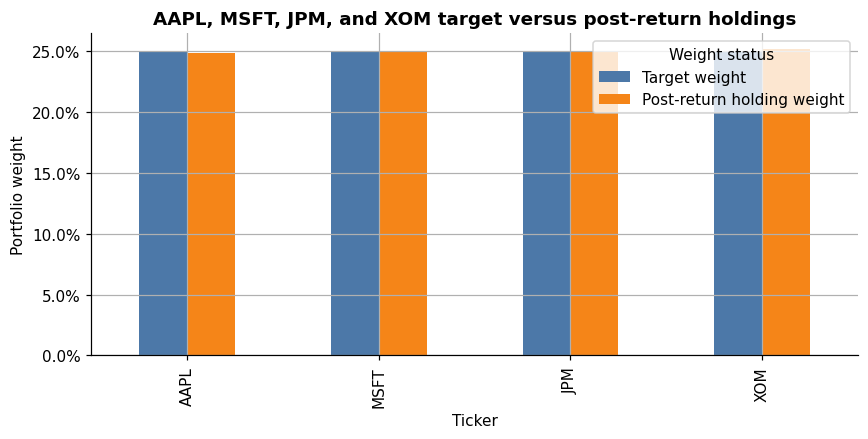

Gross portfolio return: -0.104308%
Largest positive drift: XOM 0.236367%


In [24]:
issue_11_target = first_targets["Equal"]
issue_11_return = evaluation_returns.loc[first_return_date]
issue_11_holding, issue_11_portfolio_return = drift_weights(
    issue_11_target, issue_11_return
)
issue_11_real = pd.DataFrame(
    {
        "Target weight": issue_11_target,
        "Return ending 2024-01-03": issue_11_return,
        "Post-return holding weight": issue_11_holding,
        "Holding minus target": issue_11_holding - issue_11_target,
    }
)
display(issue_11_real.style.format("{:.6%}").set_caption(
    "Equal target and post-return holding weights for 2024-01-03"
))
ax = issue_11_real[["Target weight", "Post-return holding weight"]].plot.bar(
    color=["#4C78A8", "#F58518"]
)
ax.set_title("AAPL, MSFT, JPM, and XOM target versus post-return holdings")
ax.set_xlabel("Ticker")
ax.set_ylabel("Portfolio weight")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.legend(title="Weight status")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Grouped bars compare each ticker's 25% target with its post-return holding weight after the return ending 2024-01-03.",
)
print(f"Gross portfolio return: {issue_11_portfolio_return:.6%}")
print(f"Largest positive drift: {(issue_11_holding - issue_11_target).idxmax()} {(issue_11_holding - issue_11_target).max():.6%}")
assert np.isclose(issue_11_holding.sum(), 1.0)


### Interpret Code 2

The equal-weight portfolio loses 0.104308% on the interval ending 2024-01-03. XOM earns 0.840173% and has the largest positive drift, +0.236367 percentage points, reaching 25.236367%. AAPL falls to 24.838719%. The post-return holdings still sum to one.

### Discussion questions

1. Using the displayed table, identify the ticker with the largest positive drift and explain why that change is not evidence that the target rule intentionally increased its allocation.
2. If a report calculates next month's turnover against the original 25% target rather than the pre-trade holding weights, identify which displayed column is being ignored and predict the direction of the accounting error only when the new target again equals 25%.


## Issue 12 — Which dates are rebalance dates?


A rebalance schedule determines when a new target replaces drifted holdings. This notebook invests on the first evaluation date and then on the first included trading date of each new calendar month. It does not assume that the first calendar day is a trading day.

The schedule must be fixed before comparing methods. Changing the schedule changes turnover, costs, holding paths, and which dated inputs determine each target.


### Connection to documented sources

The [`pandas` DatetimeIndex documentation](https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.html) documents calendar attributes used to identify month changes. Exchange calendars require a dedicated market-calendar source when holidays or trading sessions beyond returned dates matter.

### Controlled example

A controlled index contains business dates across January and February 2026, with the first observation deliberately beginning midmonth.

### Before Code 1

Predict which two dates the rule marks as rebalances.


In [25]:
def monthly_rebalance_dates(index):
    index = pd.DatetimeIndex(index)
    if len(index) == 0:
        raise ValueError("At least one evaluation date is required.")
    dates = [index[0]]
    dates.extend(index[i] for i in range(1, len(index)) if index[i].month != index[i - 1].month)
    return pd.DatetimeIndex(dates)


controlled_12_index = pd.bdate_range("2026-01-28", "2026-02-06")
controlled_12_schedule = pd.DataFrame(
    {
        "Evaluation date": controlled_12_index,
        "Rebalance": controlled_12_index.isin(monthly_rebalance_dates(controlled_12_index)),
    }
)
display(controlled_12_schedule.style.hide(axis="index").set_caption(
    "Artificial evaluation dates and first-included-date monthly rebalance rule"
))
print("Rebalance dates:", [str(date.date()) for date in monthly_rebalance_dates(controlled_12_index)])


Evaluation date,Rebalance
2026-01-28 00:00:00,True
2026-01-29 00:00:00,False
2026-01-30 00:00:00,False
2026-02-02 00:00:00,True
2026-02-03 00:00:00,False
2026-02-04 00:00:00,False
2026-02-05 00:00:00,False
2026-02-06 00:00:00,False


Rebalance dates: ['2026-01-28', '2026-02-02']


### Interpret Code 1

The schedule marks 2026-01-28 because it is the first evaluation observation and 2026-02-02 because it is the first included business date in February. It does not mark February 1, which is absent from the index.

### Source-grounded example

The source-grounded example constructs the schedule from the 252 common return-ending dates. For every rebalance, it records the previous included price date used to calculate the target.

### Before Code 2

Predict how many rebalances occur from 2024-01-03 through 2025-01-02 and identify the input date for the first rebalance.


In [26]:
source_rebalance_dates = monthly_rebalance_dates(evaluation_returns.index)
source_positions = source_returns.index.get_indexer(source_rebalance_dates)
if (source_positions <= 0).any():
    raise RuntimeError("Every rebalance must have an earlier source-return date.")
source_input_dates = source_returns.index[source_positions - 1]
issue_12_real = pd.DataFrame(
    {
        "Rebalance date": source_rebalance_dates,
        "Target input date": source_input_dates,
        "Calendar month": source_rebalance_dates.to_period("M").astype(str),
    }
)
display(issue_12_real.style.hide(axis="index").set_caption(
    "Monthly rebalance and preceding input dates for the common source evaluation"
))
print(f"Number of rebalances: {len(issue_12_real)}")
print(f"First rebalance/input pair: {issue_12_real.iloc[0, 0].date()} / {issue_12_real.iloc[0, 1].date()}")
assert issue_12_real["Rebalance date"].is_unique


Rebalance date,Target input date,Calendar month
2024-01-03 00:00:00,2024-01-02 00:00:00,2024-01
2024-02-01 00:00:00,2024-01-31 00:00:00,2024-02
2024-03-01 00:00:00,2024-02-29 00:00:00,2024-03
2024-04-01 00:00:00,2024-03-28 00:00:00,2024-04
2024-05-01 00:00:00,2024-04-30 00:00:00,2024-05
2024-06-03 00:00:00,2024-05-31 00:00:00,2024-06
2024-07-01 00:00:00,2024-06-28 00:00:00,2024-07
2024-08-01 00:00:00,2024-07-31 00:00:00,2024-08
2024-09-03 00:00:00,2024-08-30 00:00:00,2024-09
2024-10-01 00:00:00,2024-09-30 00:00:00,2024-10


Number of rebalances: 13
First rebalance/input pair: 2024-01-03 / 2024-01-02


### Interpret Code 2

The common evaluation has 13 rebalances: the initial 2024-01-03 investment, the first included trading date of each later month, and 2025-01-02. The first target uses information through 2024-01-02. The September rebalance occurs on 2024-09-03 and uses 2024-08-30 because the intervening calendar days are absent from the returned trading-date index.

### Discussion questions

1. The January 2025 rebalance occurs near the end of the evaluation. State whether it should be removed after observing that few later returns remain, and explain how removal would change the prespecified schedule.
2. For the first displayed rebalance, identify the target input date and explain why a same-date closing return cannot enter a target applied before that return interval ends.


## Issue 13 — How does a one-period lag prevent same-interval information use?


When a target is applied to the return ending on date $t$, a close-based feature must be calculated through an earlier close. In this notebook, the target for return-ending date $t$ uses the immediately preceding included price date $t^-$. Using the closing price at $t$ to select the weight for the return that also ends at $t$ uses information from the outcome interval.

The lag is a timing rule, not an arbitrary shift added after the calculation. Each target record must show both its input date and the return date receiving it.


### Connection to documented sources

The [`pandas.DataFrame.shift` documentation](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html) documents positional shifting. Financial validity still requires the instructor or analyst to map the shifted rows to observation, decision, execution, and return times.

### Controlled example

A four-date artificial price series forms a one-period return and a one-period momentum signal. The table compares the prior-close signal with the same-close signal for each return-ending date.

### Before Code 1

Predict which column incorrectly uses the outcome date's closing price when assigned to the same row's return.


In [27]:
controlled_13_price = pd.Series(
    [100.0, 104.0, 101.0, 106.0],
    index=pd.bdate_range("2026-03-02", periods=4),
    name="Close (USD/share)",
)
controlled_13 = pd.DataFrame({"Close (USD/share)": controlled_13_price})
controlled_13["Return ending on row"] = controlled_13_price.pct_change(fill_method=None)
controlled_13["Same-close momentum"] = controlled_13["Return ending on row"]
controlled_13["Prior-close signal applied to row"] = controlled_13["Same-close momentum"].shift(1)
display(controlled_13.style.format("{:.6f}").set_caption(
    "Artificial same-close versus prior-close signal timing"
))


,Close (USD/share),Return ending on row,Same-close momentum,Prior-close signal applied to row
2026-03-02 00:00:00,100.000000,nan,nan,nan
2026-03-03 00:00:00,104.000000,0.040000,0.040000,nan
2026-03-04 00:00:00,101.000000,-0.028846,-0.028846,0.040000
2026-03-05 00:00:00,106.000000,0.049505,0.049505,-0.028846


### Interpret Code 1

The `Same-close momentum` column is identical to the return ending on that row, so using it as the row's pre-return weight would reveal the outcome. The shifted prior-close signal uses the preceding row's observed change and is the permitted column under the declared close-to-close timing.

### Source-grounded example

The source-grounded example compares correctly lagged signal-based targets with same-date targets on the first six rebalance dates. It reports the maximum absolute weight difference but does not treat the same-date variant as a valid strategy.

### Before Code 2

Predict whether at least one same-date target differs from its correctly lagged target.


In [28]:
issue_13_rows = []
for rebalance_date, input_date in zip(source_rebalance_dates[:6], source_input_dates[:6]):
    correct = source_weights_at(input_date)["Signal based"]
    same_date = source_weights_at(rebalance_date)["Signal based"]
    issue_13_rows.append(
        {
            "Return/rebalance date": rebalance_date.date(),
            "Permitted input date": input_date.date(),
            "Same-date input used by invalid variant": rebalance_date.date(),
            "Maximum absolute weight difference": (same_date - correct).abs().max(),
            "Correct fallback": source_weights_at(input_date).attrs["signal_fallback"],
            "Same-date fallback": source_weights_at(rebalance_date).attrs["signal_fallback"],
        }
    )
issue_13_real = pd.DataFrame(issue_13_rows)
display(issue_13_real.style.format({
    "Maximum absolute weight difference": "{:.4%}"
}).hide(axis="index").set_caption(
    "Signal-based targets: prior-close rule versus invalid same-close variant"
))
print(f"Largest displayed weight difference: {issue_13_real['Maximum absolute weight difference'].max():.4%}")
assert issue_13_real["Maximum absolute weight difference"].gt(0).any()


Return/rebalance date,Permitted input date,Same-date input used by invalid variant,Maximum absolute weight difference,Correct fallback,Same-date fallback
2024-01-03,2024-01-02,2024-01-03,35.0000%,True,False
2024-02-01,2024-01-31,2024-02-01,20.1118%,False,False
2024-03-01,2024-02-29,2024-03-01,12.6679%,False,False
2024-04-01,2024-03-28,2024-04-01,2.5510%,False,False
2024-05-01,2024-04-30,2024-05-01,0.0000%,True,True
2024-06-03,2024-05-31,2024-06-03,18.2490%,False,False


Largest displayed weight difference: 35.0000%


### Interpret Code 2

At least one target changes on five of the six displayed dates. The largest difference is 35.0000 percentage points on 2024-01-03: the permitted 2024-01-02 input activates fallback, while the invalid same-close input does not. On 2024-05-01 both variants use fallback and the weight difference is zero, but that numerical match does not repair the timing; the permitted input date remains 2024-04-30.

### Discussion questions

1. Choose the displayed rebalance with the largest weight difference. State which input date is permitted and why the same-date variant cannot support a valid historical performance claim for that return interval.
2. If the two targets happen to match on one displayed date, decide whether this proves that the same-date code is valid and state which timing check remains decisive.


## Issue 14 — How is one-way turnover calculated from pre-trade holdings?


For a later rebalance, one-way turnover is

$$
u_t=\frac{1}{2}\sum_{i=1}^{N}\left|w_{i,t}^{target}-h_{i,t}^{pre}\right|.
$$

The factor one-half avoids counting the same reallocation once as a sale and again as a purchase in a fully invested risky-asset portfolio. The first movement from cash is recorded separately as turnover 1.0. Later turnover must compare the new target with the method's own pre-trade holding weights, not its previous target and not another method's holdings.


### Connection to documented sources

[Week 6](../06/week6_main.ipynb) established the course's one-way turnover convention. The [S&P Dow Jones Indices Index Mathematics Methodology](https://www.spglobal.com/spdji/en/methodology/article/index-mathematics-methodology/) discusses index turnover and rebalancing more broadly; this equation is the declared course portfolio convention.

### Controlled example

Artificial pre-trade holdings are `(53%, 27%, 20%)` and the new target is `(40%, 35%, 25%)`.

### Before Code 1

Predict the total absolute weight change and the one-way turnover.


In [29]:
def one_way_turnover(new_target, pretrade_holding, initial_from_cash=False):
    new_target = pd.Series(new_target, dtype=float)
    pretrade_holding = pd.Series(pretrade_holding, index=new_target.index, dtype=float)
    if initial_from_cash:
        return float(new_target.abs().sum())
    return float(0.5 * (new_target - pretrade_holding).abs().sum())


controlled_14_pretrade = pd.Series([0.53, 0.27, 0.20], index=list("ABC"))
controlled_14_target = pd.Series([0.40, 0.35, 0.25], index=list("ABC"))
controlled_14 = pd.DataFrame(
    {
        "Pre-trade holding weight": controlled_14_pretrade,
        "New target weight": controlled_14_target,
        "Absolute change": (controlled_14_target - controlled_14_pretrade).abs(),
    }
)
controlled_14_turnover = one_way_turnover(controlled_14_target, controlled_14_pretrade)
display(controlled_14.style.format("{:.2%}").set_caption(
    "Artificial pre-trade holdings, new target, and absolute trades"
))
print(f"Total absolute change: {controlled_14['Absolute change'].sum():.2%}")
print(f"One-way turnover: {controlled_14_turnover:.2%}")


,Pre-trade holding weight,New target weight,Absolute change
A,53.00%,40.00%,13.00%
B,27.00%,35.00%,8.00%
C,20.00%,25.00%,5.00%


Total absolute change: 26.00%
One-way turnover: 13.00%


### Interpret Code 1

The total absolute change is 26.00%, consisting of a 13-point sale and purchases totaling 13 points. One-way turnover is therefore 13.00%.

### Source-grounded example

The source-grounded example starts both equal and inverse-volatility methods on 2024-01-03, lets holdings drift through January 31, and compares each method's own pre-trade holdings with its February 1 target.

### Before Code 2

Predict whether equal weighting has zero February turnover and which method has the larger value.


In [30]:
def holdings_before_date(initial_target, returns_through_previous_date):
    held = pd.Series(initial_target, dtype=float).copy()
    for _, asset_return in returns_through_previous_date.iterrows():
        held, _ = drift_weights(held, asset_return)
    return held


february_rebalance = pd.Timestamp("2024-02-01")
january_returns = evaluation_returns.loc[EVALUATION_START:"2024-01-31"]
issue_14_rows = []
for method in ["Equal", "Inverse volatility"]:
    initial_target = source_weights_at(formation_date)[method]
    pretrade = holdings_before_date(initial_target, january_returns)
    feb_input_date = source_returns.index[source_returns.index.get_loc(february_rebalance) - 1]
    new_target = source_weights_at(feb_input_date)[method]
    issue_14_rows.append(
        {
            "Method": method,
            "February input date": feb_input_date.date(),
            "Maximum pre-trade deviation from new target": (pretrade - new_target).abs().max(),
            "One-way turnover": one_way_turnover(new_target, pretrade),
        }
    )
issue_14_real = pd.DataFrame(issue_14_rows).set_index("Method")
display(issue_14_real.style.format({
    "Maximum pre-trade deviation from new target": "{:.4%}",
    "One-way turnover": "{:.4%}",
}).set_caption(
    "February 1, 2024 turnover after source-derived January price returns"
))


,February input date,Maximum pre-trade deviation from new target,One-way turnover
Method,,,
Equal,2024-01-31,1.2558%,1.2558%
Inverse volatility,2024-01-31,2.5859%,3.4712%


### Interpret Code 2

After January returns, equal weighting has February one-way turnover of 1.2558%. Inverse-volatility weighting has 3.4712%, and its largest asset-level deviation between pre-trade holdings and the new target is 2.5859%. The larger value reflects both holding drift and a changed volatility-based target.

### Discussion questions

1. Using the displayed results, identify which method has larger February turnover and explain why its new target—not merely weight drift—must be inspected before attributing the difference.
2. Suppose the equal method's turnover were calculated against its January 3 target instead of January 31 pre-trade holdings. State which formula input would be wrong and why the resulting cost would be understated when holdings drifted.


## Issue 15 — How does turnover convert gross return into net return?


With gross portfolio return $r_t^{gross}$, one-way turnover $u_t$, and assumed proportional one-way cost rate $c$, Week 6 uses

$$
r_t^{net}=r_t^{gross}-cu_t.
$$

Four basis points equal $4/10{,}000=0.0004$ in decimal-return units. A method with the same gross return but larger turnover receives a larger cost deduction. The teaching cost is not an observed commission, quote, or fill.


### Connection to documented sources

The gross-to-net identity carries forward the documented [Week 6](../06/week6_main.ipynb) convention. It is a teaching calculation; the [yfinance download API](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html) does not provide the assumed commission, half-spread, or slippage with these daily price rows.

### Controlled example

Three artificial rows have gross returns `(1.00%, 1.00%, -0.50%)` and one-way turnover `(0%, 25%, 80%)` under a 4-basis-point rate.

### Before Code 1

Predict the largest cost deduction in basis points and identify which rows retain the same gross return but have different net returns.


In [31]:
controlled_15 = pd.DataFrame(
    {
        "Gross return (decimal)": [0.0100, 0.0100, -0.0050],
        "One-way turnover": [0.00, 0.25, 0.80],
    },
    index=["Row 1", "Row 2", "Row 3"],
)
controlled_15["Cost deduction (decimal return)"] = (
    controlled_15["One-way turnover"] * TEACHING_COST_BP / 10_000
)
controlled_15["Net return (decimal)"] = (
    controlled_15["Gross return (decimal)"]
    - controlled_15["Cost deduction (decimal return)"]
)
display(controlled_15.style.format("{:.6f}").set_caption(
    "Artificial gross-to-net ledger; 4 basis points per unit of one-way turnover"
))
print(f"Largest cost deduction: {controlled_15['Cost deduction (decimal return)'].max() * 10_000:.2f} basis points")


,Gross return (decimal),One-way turnover,Cost deduction (decimal return),Net return (decimal)
Row 1,0.010000,0.000000,0.000000,0.010000
Row 2,0.010000,0.250000,0.000100,0.009900
Row 3,-0.005000,0.800000,0.000320,-0.005320


Largest cost deduction: 3.20 basis points


### Interpret Code 1

The largest deduction is 3.20 basis points on 80% turnover. Rows 1 and 2 both earn 1.00% gross, but Row 2 nets 0.9900% because its 25% turnover deducts 1 basis point; Row 1 remains at 1.00%.

### Source-grounded example

The source-grounded example combines the first investment and February turnover for equal and inverse-volatility targets. It displays the cost deduction separately from the source-derived asset returns.

### Before Code 2

Predict whether both methods pay 4 basis points at initial investment and which pays the larger February deduction.


In [32]:
issue_15_rows = []
for method in ["Equal", "Inverse volatility"]:
    initial_turnover = one_way_turnover(
        source_weights_at(formation_date)[method],
        pd.Series(0.0, index=TICKERS),
        initial_from_cash=True,
    )
    feb_turnover = issue_14_real.loc[method, "One-way turnover"]
    issue_15_rows.extend(
        [
            {"Method": method, "Rebalance date": EVALUATION_START.date(), "One-way turnover": initial_turnover},
            {"Method": method, "Rebalance date": february_rebalance.date(), "One-way turnover": feb_turnover},
        ]
    )
issue_15_real = pd.DataFrame(issue_15_rows)
issue_15_real["Assumed cost rate (basis points)"] = TEACHING_COST_BP
issue_15_real["Cost deduction (decimal return)"] = (
    issue_15_real["One-way turnover"] * TEACHING_COST_BP / 10_000
)
display(issue_15_real.style.format({
    "One-way turnover": "{:.4%}",
    "Assumed cost rate (basis points)": "{:.1f}",
    "Cost deduction (decimal return)": "{:.6f}",
}).hide(axis="index").set_caption(
    "Source-return portfolio targets with instructor-created transaction costs"
))


Method,Rebalance date,One-way turnover,Assumed cost rate (basis points),Cost deduction (decimal return)
Equal,2024-01-03,100.0000%,4.0,0.000400
Equal,2024-02-01,1.2558%,4.0,0.000005
Inverse volatility,2024-01-03,100.0000%,4.0,0.000400
Inverse volatility,2024-02-01,3.4712%,4.0,0.000014


### Interpret Code 2

Both methods invest 100% from cash on 2024-01-03 and therefore each deducts 0.000400, or 4 basis points. On 2024-02-01, equal weighting's 1.2558% turnover deducts about 0.000005, while inverse volatility's 3.4712% turnover deducts about 0.000014. The costs are teaching assumptions derived from turnover, not source-provided observations.

### Discussion questions

1. The initial rows have the same cost deduction. Explain why this equality follows from full investment from cash rather than from equal subsequent trading intensity.
2. If the February cost were copied from equal weighting into inverse volatility despite different displayed turnover, identify the violated gross-to-net identity and the exact column that must be recalculated.


## Issue 16 — How can target-weight concentration be summarized?


The sum of squared target weights is

$$
H=\sum_{i=1}^{N}w_i^2.
$$

For nonnegative weights that sum to one, a larger value indicates that more portfolio weight is concentrated in fewer positions. Its reciprocal, $N_{eff}=1/H$, is often interpreted as an effective number of equally weighted positions. These measures summarize target weights only; they do not measure return correlation, liquidity, sector exposure, or loss risk.


### Connection to documented sources

The U.S. Department of Justice page on the [Herfindahl–Hirschman Index](https://www.justice.gov/atr/herfindahl-hirschman-index) defines concentration as the sum of squared market shares. This notebook applies the same mathematical form to portfolio weights; it does not import antitrust interpretation thresholds into portfolio analysis.

### Controlled example

The controlled example compares equal `(25%,25%,25%,25%)`, concentrated `(60%,40%,0%,0%)`, and intermediate `(40%,30%,20%,10%)` targets.

### Before Code 1

Predict which vector has the largest squared-weight sum and the smallest effective number of positions.


In [33]:
def weight_concentration(weights):
    weights = pd.Series(weights, dtype=float)
    h = float((weights ** 2).sum())
    return h, 1 / h


controlled_16_vectors = {
    "Equal": [0.25, 0.25, 0.25, 0.25],
    "Concentrated": [0.60, 0.40, 0.00, 0.00],
    "Intermediate": [0.40, 0.30, 0.20, 0.10],
}
controlled_16 = pd.DataFrame(
    [
        {"Target": name, "Sum of squared weights": weight_concentration(values)[0], "Effective number": weight_concentration(values)[1]}
        for name, values in controlled_16_vectors.items()
    ]
).set_index("Target")
display(controlled_16.style.format("{:.4f}").set_caption(
    "Concentration of three artificial long-only target vectors"
))


,Sum of squared weights,Effective number
Target,,
Equal,0.2500,4.0000
Concentrated,0.5200,1.9231
Intermediate,0.3000,3.3333


### Interpret Code 1

The concentrated target has the largest squared-weight sum, 0.5200, and the smallest effective number, 1.9231. Equal weighting has 0.2500 and an effective number of 4.0000. These values do not incorporate correlations or return outcomes.

### Source-grounded example

The source-grounded example computes concentration for the four first-date target vectors from Issue 9 and plots the values.

### Before Code 2

Predict which first-date method has the largest concentration and whether any conclusion about realized portfolio risk follows from that number alone.


,Sum of squared weights,Effective number
Equal,0.2500,4.0000
Market capitalization,0.3810,2.6244
Signal based,0.2500,4.0000
Inverse volatility,0.2650,3.7731


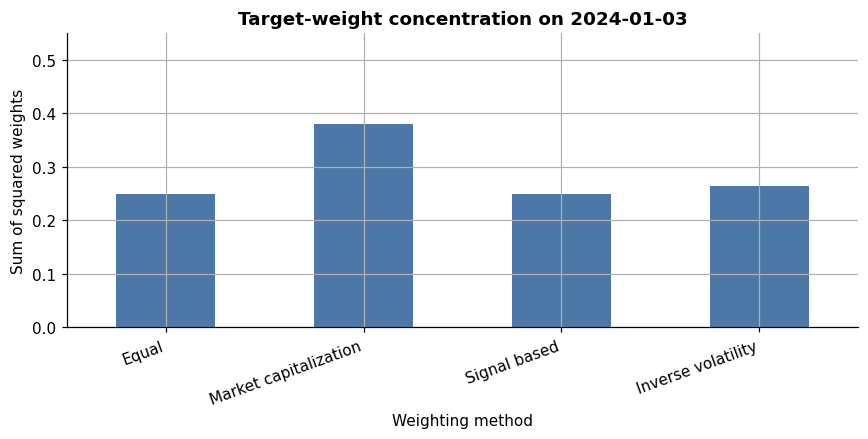

Largest concentration: Market capitalization 0.3810


In [34]:
issue_16_real = pd.DataFrame(
    {
        method: pd.Series(weight_concentration(first_targets[method]), index=["Sum of squared weights", "Effective number"])
        for method in first_targets.columns
    }
).T
display(issue_16_real.style.format("{:.4f}").set_caption(
    "Concentration of source-grounded targets applied on 2024-01-03"
))
ax = issue_16_real["Sum of squared weights"].plot.bar(color="#4C78A8")
ax.set_title("Target-weight concentration on 2024-01-03")
ax.set_xlabel("Weighting method")
ax.set_ylabel("Sum of squared weights")
ax.set_ylim(0, max(0.55, issue_16_real["Sum of squared weights"].max() * 1.15))
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Bars compare the sum of squared target weights for equal, market-capitalization, signal-based, and inverse-volatility allocations applied on 2024-01-03.",
)
print(f"Largest concentration: {issue_16_real['Sum of squared weights'].idxmax()} {issue_16_real['Sum of squared weights'].max():.4f}")


### Interpret Code 2

Market-capitalization weighting is the most concentrated first-date target, with a squared-weight sum of 0.3810 and effective number 2.6244. Equal weighting and the signal-based fallback each have 0.2500 and effective number 4.0000; inverse volatility has 0.2650 and 3.7731. These target summaries do not determine portfolio volatility without return covariances.

### Discussion questions

1. Using the displayed table, identify the most concentrated first-date target and state one risk property that cannot be inferred without the asset return covariance matrix.
2. Two methods have the same squared-weight sum but allocate to different tickers. Decide whether they have the same portfolio volatility and name the additional inputs needed.


## Issue 17 — How are weighting methods compared in one common backtest?


A method comparison must hold fixed the asset universe, return dates, price-return convention, information lag, cap, rebalance dates, turnover convention, cost rate, target return, and performance formulas. Only the weighting rule changes.

The backtest below applies each target before the dated asset return, deducts the Week 6 teaching cost from that period's gross portfolio return, and lets risky-asset holdings drift using the gross asset returns. The cost is treated as a separate proportional wealth deduction and does not alter the relative risky-asset weights in the drift calculation. No terminal liquidation is included.


### Connection to documented sources

[Week 7](../07/week7_main.ipynb) established the performance formulas and evidence limits. DeMiguel, Garlappi, and Uppal (2009), [Optimal Versus Naive Diversification](https://doi.org/10.1093/rfs/hhm075), show why `1/N` belongs in empirical comparisons; their results do not rank this notebook's methods.

### Controlled example

A six-date artificial two-asset example rebalances on the first and fourth rows. Its target table is fixed before the returns are processed.

### Before Code 1

Predict whether the first row records turnover 1.0 and whether the later rebalance compares the new target with drifted holdings.


In [35]:
def run_target_backtest(asset_returns, target_by_date, cost_bp=4.0):
    asset_returns = pd.DataFrame(asset_returns, dtype=float)
    target_by_date = {pd.Timestamp(date): pd.Series(weight, index=asset_returns.columns, dtype=float) for date, weight in target_by_date.items()}
    held = pd.Series(0.0, index=asset_returns.columns)
    rows = []
    for date, day_return in asset_returns.iterrows():
        rebalanced = date in target_by_date
        if rebalanced:
            target = target_by_date[date]
            initial = np.isclose(held.abs().sum(), 0.0)
            turnover = one_way_turnover(target, held, initial_from_cash=initial)
            held = target.copy()
            target_h = weight_concentration(target)[0]
        else:
            turnover = 0.0
            target_h = np.nan
        gross_return = float(held @ day_return)
        cost = turnover * cost_bp / 10_000
        net_return = gross_return - cost
        pre_drift = held.copy()
        held, _ = drift_weights(held, day_return)
        rows.append(
            {
                "date": date,
                "rebalanced": rebalanced,
                "turnover": turnover,
                "cost": cost,
                "gross_return": gross_return,
                "net_return": net_return,
                "target_concentration": target_h,
                "pre_return_weight_sum": pre_drift.sum(),
                "post_return_weight_sum": held.sum(),
            }
        )
    result = pd.DataFrame(rows).set_index("date")
    result["gross_wealth"] = (1 + result["gross_return"]).cumprod()
    result["net_wealth"] = (1 + result["net_return"]).cumprod()
    return result


controlled_17_returns = pd.DataFrame(
    {
        "A": [0.02, -0.01, 0.01, 0.03, -0.02, 0.01],
        "B": [0.00, 0.02, -0.01, -0.01, 0.01, 0.00],
    },
    index=pd.bdate_range("2026-04-01", periods=6),
)
controlled_17_targets = {
    controlled_17_returns.index[0]: pd.Series([0.50, 0.50], index=["A", "B"]),
    controlled_17_returns.index[3]: pd.Series([0.70, 0.30], index=["A", "B"]),
}
controlled_17 = run_target_backtest(controlled_17_returns, controlled_17_targets, cost_bp=4.0)
display(controlled_17.style.format({
    "turnover": "{:.4%}", "cost": "{:.6f}", "gross_return": "{:.4%}",
    "net_return": "{:.4%}", "target_concentration": "{:.4f}",
    "pre_return_weight_sum": "{:.6f}", "post_return_weight_sum": "{:.6f}",
    "gross_wealth": "{:.6f}", "net_wealth": "{:.6f}",
}).set_caption("Artificial target-weight backtest with a 4-basis-point one-way cost"))
assert np.isclose(controlled_17.iloc[0]["turnover"], 1.0)
assert np.allclose(controlled_17["cost"], controlled_17["turnover"] * 4 / 10_000)


,rebalanced,turnover,cost,gross_return,net_return,target_concentration,pre_return_weight_sum,post_return_weight_sum,gross_wealth,net_wealth
date,,,,,,,,,,
2026-04-01 00:00:00,True,100.0000%,0.000400,1.0000%,0.9600%,0.5000,1.000000,1.000000,1.010000,1.009600
2026-04-02 00:00:00,False,0.0000%,0.000000,0.4851%,0.4851%,nan,1.000000,1.000000,1.014900,1.014498
2026-04-03 00:00:00,False,0.0000%,0.000000,-0.0050%,-0.0050%,nan,1.000000,1.000000,1.014849,1.014447
2026-04-06 00:00:00,True,19.7512%,0.000079,1.8000%,1.7921%,0.5800,1.000000,1.000000,1.033116,1.032627
2026-04-07 00:00:00,False,0.0000%,0.000000,-1.1248%,-1.1248%,nan,1.000000,1.000000,1.021496,1.021012
2026-04-08 00:00:00,False,0.0000%,0.000000,0.7020%,0.7020%,nan,1.000000,1.000000,1.028667,1.028180


### Interpret Code 1

The first row records turnover 1.0000 and deducts 0.000400. The fourth row compares the 70/30 target with holdings that drifted over the first three returns and records nonzero turnover rather than comparing with the original 50/50 target.

### Source-grounded example

The source-grounded example generates monthly target maps for all four methods, runs them on the same 252 return dates, and summarizes Week 7 net performance, maximum drawdown, turnover, and target concentration.

### Before Code 2

Predict which method has the highest total turnover and whether every method has exactly 252 net-return observations.


,Observations,Cumulative net return,Compounded annualized net return,Annualized net volatility,Net Sharpe ratio (5% annual target),Maximum net drawdown,Total one-way turnover,Mean target concentration,Fallback count
Equal,252,22.5906%,22.5906%,12.7277%,1.2810,-8.2632%,1.2123,0.2500,0
Market capitalization,252,22.4854%,22.4854%,15.9022%,1.0485,-11.3446%,1.0000,0.3789,0
Signal based,252,27.8077%,27.8077%,16.9695%,1.2434,-12.5061%,5.9493,0.3946,3
Inverse volatility,252,20.3041%,20.3041%,12.7248%,1.1333,-8.5359%,2.2894,0.2615,0


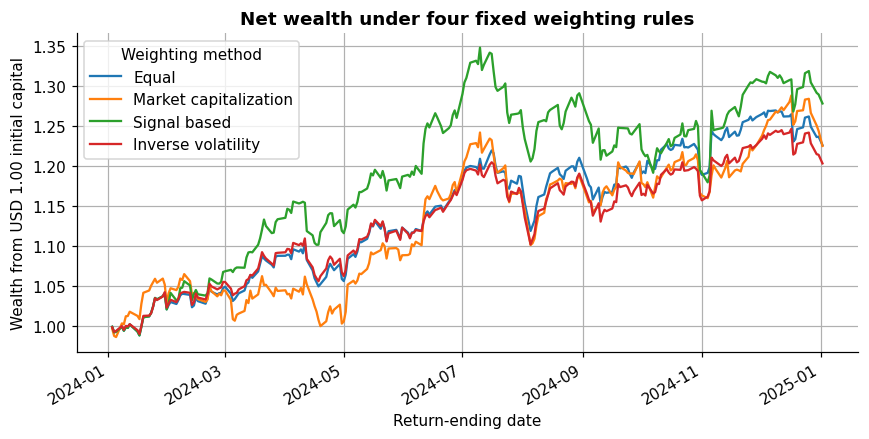

In [36]:
METHODS = ["Equal", "Market capitalization", "Signal based", "Inverse volatility"]


def make_target_map(method, cap=0.60, vol_window=20):
    targets = {}
    fallbacks = {}
    for rebalance_date, input_date in zip(source_rebalance_dates, source_input_dates):
        table = source_weights_at(input_date, cap=cap, vol_window=vol_window)
        targets[rebalance_date] = table[method]
        fallbacks[rebalance_date] = bool(table.attrs["signal_fallback"]) if method == "Signal based" else False
    return targets, pd.Series(fallbacks, name="fallback_used")


def summarize_backtest(result, target_fallbacks):
    net = result["net_return"]
    observations = len(net)
    annualized_return = (1 + net).prod() ** (PERIODS_PER_YEAR / observations) - 1
    annualized_volatility = net.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
    annual_target_periodic = (1 + ANNUAL_TARGET_RETURN) ** (1 / PERIODS_PER_YEAR) - 1
    sharpe = (
        (net.mean() - annual_target_periodic) / net.std(ddof=1) * np.sqrt(PERIODS_PER_YEAR)
        if net.std(ddof=1) > 0 else np.nan
    )
    wealth = (1 + net).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    return pd.Series(
        {
            "Observations": observations,
            "Cumulative net return": wealth.iloc[-1] - 1,
            "Compounded annualized net return": annualized_return,
            "Annualized net volatility": annualized_volatility,
            "Net Sharpe ratio (5% annual target)": sharpe,
            "Maximum net drawdown": drawdown.min(),
            "Total one-way turnover": result["turnover"].sum(),
            "Mean target concentration": result["target_concentration"].dropna().mean(),
            "Fallback count": int(target_fallbacks.sum()),
        }
    )


baseline_targets = {}
baseline_fallbacks = {}
baseline_results = {}
for method in METHODS:
    baseline_targets[method], baseline_fallbacks[method] = make_target_map(method)
    baseline_results[method] = run_target_backtest(
        evaluation_returns, baseline_targets[method], cost_bp=TEACHING_COST_BP
    )

baseline_comparison = pd.DataFrame(
    {method: summarize_backtest(baseline_results[method], baseline_fallbacks[method]) for method in METHODS}
).T
display(baseline_comparison.style.format({
    "Observations": "{:.0f}",
    "Cumulative net return": "{:.4%}",
    "Compounded annualized net return": "{:.4%}",
    "Annualized net volatility": "{:.4%}",
    "Net Sharpe ratio (5% annual target)": "{:.4f}",
    "Maximum net drawdown": "{:.4%}",
    "Total one-way turnover": "{:.4f}",
    "Mean target concentration": "{:.4f}",
    "Fallback count": "{:.0f}",
}).set_caption(
    "Common-condition source-grounded comparison; daily price returns, 2024-01-03 through 2025-01-02, net of teaching cost"
))
wealth_paths = pd.DataFrame(
    {method: result["net_wealth"] for method, result in baseline_results.items()}
)
ax = wealth_paths.plot()
ax.set_title("Net wealth under four fixed weighting rules")
ax.set_xlabel("Return-ending date")
ax.set_ylabel("Wealth from USD 1.00 initial capital")
ax.legend(title="Weighting method")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Line chart shows net wealth from one dollar for four weighting methods over the common 2024-01-03 to 2025-01-02 evaluation period.",
)
assert baseline_comparison["Observations"].eq(252).all()
assert all(result.index.equals(evaluation_returns.index) for result in baseline_results.values())


### Interpret Code 2

Every method has 252 net-return observations under identical dates and cost rules. Signal-based weighting has the highest cumulative net return, 27.8077%, and the highest turnover, 5.9493; it uses fallback at three rebalances. Inverse volatility has the lowest annualized net volatility, 12.7248%, narrowly below equal weighting's 12.7277%. Equal weighting has the highest displayed net Sharpe ratio, 1.2810, under the common 5% annual target. The metrics therefore do not produce one criterion-free winner.

### Discussion questions

1. Identify the method with the highest cumulative net return and the method with the lowest annualized net volatility. If they differ, explain why the table does not contain one metric-free winner.
2. Identify the method with the highest turnover and quantify its gross-to-net mechanism using the common 4-basis-point rate. State why the result cannot be attributed to the weighting formula if its rebalance schedule or cost differed from the other methods.


## Issue 18 — What does position-cap sensitivity reveal?


Cap sensitivity changes only $w_{max}$ while holding the data, method inputs, dates, lag, rebalance schedule, turnover convention, and cost fixed. A tighter feasible cap can redistribute weight away from a dominant input, but methods whose uncapped weights already fall below the cap will not change.

The comparison is a sensitivity analysis. It does not prove that the tighter or looser cap is economically optimal.


### Connection to documented sources

The [S&P Dow Jones Indices Index Mathematics Methodology](https://www.spglobal.com/spdji/en/methodology/article/index-mathematics-methodology/) documents capped index categories. This notebook's 40% and 60% limits and redistribution rule remain teaching assumptions.

### Controlled example

Artificial raw inputs `(8, 1, 1, 0)` are normalized under 60% and 40% caps.

### Before Code 1

Predict which positions change and whether both capped vectors remain fully invested.


In [37]:
controlled_18_raw = pd.Series([8.0, 1.0, 1.0, 0.0], index=list("ABCD"))
controlled_18_w60, _ = normalize_with_cap(controlled_18_raw, cap=0.60)
controlled_18_w40, _ = normalize_with_cap(controlled_18_raw, cap=0.40)
controlled_18 = pd.DataFrame(
    {
        "60% cap": controlled_18_w60,
        "40% cap": controlled_18_w40,
        "40% minus 60%": controlled_18_w40 - controlled_18_w60,
    }
)
display(controlled_18.style.format("{:+.2%}").set_caption(
    "Artificial position-cap sensitivity with all other inputs fixed"
))
print(f"60% vector sum: {controlled_18_w60.sum():.4f}")
print(f"40% vector sum: {controlled_18_w40.sum():.4f}")


,60% cap,40% cap,40% minus 60%
A,+60.00%,+40.00%,-20.00%
B,+20.00%,+30.00%,+10.00%
C,+20.00%,+30.00%,+10.00%
D,+0.00%,+0.00%,+0.00%


60% vector sum: 1.0000
40% vector sum: 1.0000


### Interpret Code 1

The 60% result is `(60%, 20%, 20%, 0%)`; the 40% result is `(40%, 30%, 30%, 0%)`. Asset A loses 20 percentage points and B and C each gain 10. Both vectors sum to 1.0000.

### Source-grounded example

The source-grounded example reruns all four methods with a 40% cap. Every other baseline condition remains fixed, and differences are reported relative to the 60% baseline.

### Before Code 2

Predict which method's mean target concentration changes the most and whether equal weighting changes at all.


,60% cap mean concentration,40% cap mean concentration,Concentration change,60% cap cumulative net return,40% cap cumulative net return,Net-return change
Equal,0.2500,0.2500,+0.0000,22.5906%,22.5906%,+0.0000%
Market capitalization,0.3789,0.3404,-0.0385,22.4854%,23.0931%,+0.6077%
Signal based,0.3946,0.3059,-0.0887,27.8077%,29.4832%,+1.6755%
Inverse volatility,0.2615,0.2615,+0.0000,20.3041%,20.3041%,+0.0000%


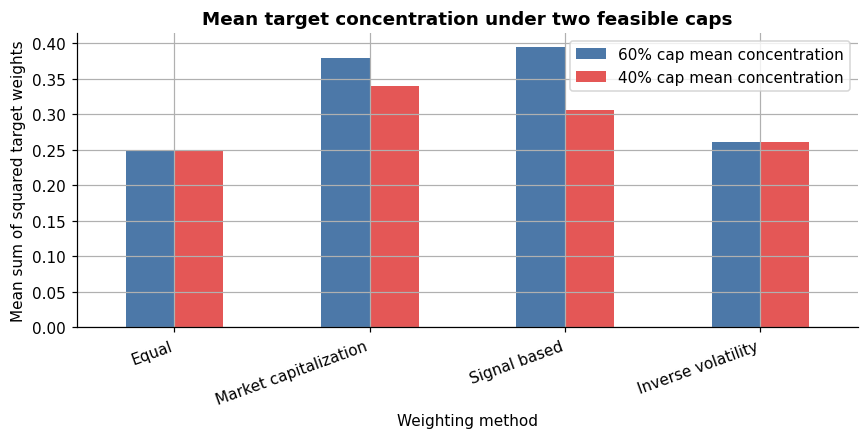

In [38]:
cap40_results = {}
cap40_fallbacks = {}
for method in METHODS:
    targets, cap40_fallbacks[method] = make_target_map(method, cap=0.40)
    cap40_results[method] = run_target_backtest(
        evaluation_returns, targets, cost_bp=TEACHING_COST_BP
    )
cap40_comparison = pd.DataFrame(
    {method: summarize_backtest(cap40_results[method], cap40_fallbacks[method]) for method in METHODS}
).T
issue_18_real = pd.DataFrame(
    {
        "60% cap mean concentration": baseline_comparison["Mean target concentration"],
        "40% cap mean concentration": cap40_comparison["Mean target concentration"],
        "Concentration change": cap40_comparison["Mean target concentration"] - baseline_comparison["Mean target concentration"],
        "60% cap cumulative net return": baseline_comparison["Cumulative net return"],
        "40% cap cumulative net return": cap40_comparison["Cumulative net return"],
        "Net-return change": cap40_comparison["Cumulative net return"] - baseline_comparison["Cumulative net return"],
    }
)
display(issue_18_real.style.format({
    "60% cap mean concentration": "{:.4f}",
    "40% cap mean concentration": "{:.4f}",
    "Concentration change": "{:+.4f}",
    "60% cap cumulative net return": "{:.4%}",
    "40% cap cumulative net return": "{:.4%}",
    "Net-return change": "{:+.4%}",
}).set_caption(
    "Position-cap sensitivity; common source data, dates, lag, monthly schedule, and 4-basis-point cost"
))
ax = issue_18_real[["60% cap mean concentration", "40% cap mean concentration"]].plot.bar(
    color=["#4C78A8", "#E45756"]
)
ax.set_title("Mean target concentration under two feasible caps")
ax.set_xlabel("Weighting method")
ax.set_ylabel("Mean sum of squared target weights")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
show_figure_with_alt_text(
    ax.figure,
    "Grouped bars compare each method's mean target concentration under 60 percent and 40 percent individual-position caps.",
)


### Interpret Code 2

Signal-based weighting has the largest concentration response: tightening the cap reduces its mean squared-weight sum by 0.0887, from 0.3946 to 0.3059, while cumulative net return rises 1.6755 percentage points to 29.4832%. Market capitalization falls 0.0385 in concentration and rises 0.6077 points in net return. Equal and inverse-volatility results do not change because their targets already satisfy 40%. These are period-specific sensitivity results.

### Discussion questions

1. Identify the method with the largest absolute concentration change. State whether its cumulative net-return change has the same sign and explain why one evaluation period cannot establish that the cap caused a generally beneficial outcome.
2. Equal weighting should be unchanged under both feasible caps. Use the displayed values to verify that statement and identify which common condition would have to change before equal targets could differ.


## Issue 19 — What does inverse-volatility lookback sensitivity reveal?


Lookback sensitivity changes the volatility-estimation window while keeping the method, universe, data, dates, cap, lag, schedule, cost, and performance formulas fixed. Different windows can change every monthly target and therefore change concentration, turnover, and net performance.

Inspecting both results is not permission to choose the better historical window and then call the same evaluation period unused. A method-selection claim requires a separate selection period and subsequent evaluation evidence.


### Connection to documented sources

The [`pandas` rolling standard-deviation documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.api.typing.Rolling.std.html) defines the rolling calculation. Week 7's repeated-selection example explains why choosing a setting after viewing the evaluation result creates selection bias.

### Controlled example

Two artificial volatility pairs show how 20-return and 60-return estimates can reverse the relative ordering of two assets.

### Before Code 1

Predict whether the asset receiving the larger inverse-volatility target changes between the two windows.


In [39]:
controlled_19 = pd.DataFrame(
    {
        "20-return volatility": [0.010, 0.020],
        "60-return volatility": [0.025, 0.015],
    },
    index=["Asset A", "Asset B"],
)
controlled_19["20-return target"] = normalize_positive(1 / controlled_19["20-return volatility"])
controlled_19["60-return target"] = normalize_positive(1 / controlled_19["60-return volatility"])
display(controlled_19.style.format({
    "20-return volatility": "{:.2%}", "60-return volatility": "{:.2%}",
    "20-return target": "{:.2%}", "60-return target": "{:.2%}",
}).set_caption("Artificial inverse-volatility lookback sensitivity"))


,20-return volatility,60-return volatility,20-return target,60-return target
Asset A,1.00%,2.50%,66.67%,37.50%
Asset B,2.00%,1.50%,33.33%,62.50%


### Interpret Code 1

Asset A receives 66.67% under the 20-return estimate because its volatility is lower there. Asset B receives 62.50% under the 60-return estimate because the ordering reverses. The example shows sensitivity, not which window predicts future risk better.

### Source-grounded example

The source-grounded example compares 20-return and 60-return inverse-volatility backtests under the common 60% cap and monthly schedule.

### Before Code 2

Predict whether the window with lower annualized net volatility also has lower turnover; record both directions before running.


In [40]:
iv_window_results = {}
for window in [20, 60]:
    targets, fallbacks = make_target_map("Inverse volatility", cap=POSITION_CAP, vol_window=window)
    result = run_target_backtest(evaluation_returns, targets, cost_bp=TEACHING_COST_BP)
    iv_window_results[window] = summarize_backtest(result, fallbacks)
issue_19_real = pd.DataFrame(iv_window_results).T
issue_19_real.index.name = "Volatility lookback (returns)"
display(issue_19_real.style.format({
    "Observations": "{:.0f}",
    "Cumulative net return": "{:.4%}",
    "Compounded annualized net return": "{:.4%}",
    "Annualized net volatility": "{:.4%}",
    "Net Sharpe ratio (5% annual target)": "{:.4f}",
    "Maximum net drawdown": "{:.4%}",
    "Total one-way turnover": "{:.4f}",
    "Mean target concentration": "{:.4f}",
    "Fallback count": "{:.0f}",
}).set_caption(
    "Inverse-volatility lookback sensitivity; all non-window conditions fixed"
))


,Observations,Cumulative net return,Compounded annualized net return,Annualized net volatility,Net Sharpe ratio (5% annual target),Maximum net drawdown,Total one-way turnover,Mean target concentration,Fallback count
Volatility lookback (returns),,,,,,,,,
20,252,20.3041%,20.3041%,12.7248%,1.1333,-8.5359%,2.2894,0.2615,0
60,252,21.3773%,21.3773%,12.6167%,1.2123,-8.0085%,1.4920,0.2557,0


### Interpret Code 2

The 60-return version has lower annualized net volatility, 12.6167% versus 12.7248%, and lower total one-way turnover, 1.4920 versus 2.2894. It also has a higher cumulative net return, 21.3773% versus 20.3041%, in this evaluation. Because both rows use the same inspected period, the table is sensitivity evidence and cannot serve as both setting selection and unused evaluation.

### Discussion questions

1. Identify which window has lower annualized net volatility and which has lower total turnover. If the answers differ, explain why selecting a window requires an explicit criterion fixed before evaluation.
2. Suppose a team reports only the historically higher Sharpe ratio from the two displayed rows. State what selection information is omitted and which new period would be required for a subsequent evaluation claim.


## Issue 20 — What conclusion survives a weighting-method audit?


A backtest audit checks whether each result corresponds to the declared data, inputs, timing, constraints, implementation, cost, benchmark, and evaluation procedure. A passed calculation check supports the calculation under those conditions. It does not prove that an input was known point in time, that simulated execution was attainable, or that the same ranking will persist.

The final statement should name the observed metric and period, then separately state the limitation that prevents a broader claim.


### Connection to documented sources

The [yfinance documentation](https://ranaroussi.github.io/yfinance/) states that yfinance is an open-source tool using Yahoo's publicly available APIs and directs users to Yahoo's terms. S&P methodology sources define index calculations but do not certify this notebook as an index replication.

### Controlled example

A controlled audit table includes two passing statements, one unsupported point-in-time claim, and one comparison with unequal costs.

### Before Code 1

Predict which rows cannot support a method-comparison conclusion and state whether each requires correction or a limitation label.


In [41]:
controlled_20 = pd.DataFrame(
    [
        ["All target weights are finite, nonnegative, capped, and sum to one", "Pass", "Calculation check passed"],
        ["All methods use identical evaluation dates", "Pass", "Comparison dates aligned"],
        ["Provider shares were known to investors on the displayed record date", "Unsupported", "Point-in-time availability not verified"],
        ["Signal method uses 4 bp but equal method uses 0 bp", "Fail", "Use one common cost before comparison"],
    ],
    columns=["Audit statement", "Status", "Required conclusion or action"],
)
display(controlled_20.style.hide(axis="index").set_caption(
    "Controlled weighting-method audit examples"
))
print(controlled_20["Status"].value_counts().to_string())


Audit statement,Status,Required conclusion or action
"All target weights are finite, nonnegative, capped, and sum to one",Pass,Calculation check passed
All methods use identical evaluation dates,Pass,Comparison dates aligned
Provider shares were known to investors on the displayed record date,Unsupported,Point-in-time availability not verified
Signal method uses 4 bp but equal method uses 0 bp,Fail,Use one common cost before comparison


Status
Pass           2
Unsupported    1
Fail           1


### Interpret Code 1

Two rows pass. The shares-availability statement is unsupported and must remain a limitation unless point-in-time publication evidence is obtained. The unequal-cost row fails the comparison design and must be corrected before attributing a difference to weighting.

### Source-grounded example

The source-grounded audit checks the executed baseline and records the provider-shares and execution limitations separately from passed calculations.

### Before Code 2

Predict how many audit rows pass and how many remain limitations rather than calculation failures.


In [42]:
issue_20_checks = [
    ("Four fixed source tickers appear in every return row", evaluation_returns.columns.tolist() == TICKERS, ""),
    ("Every method has the same 252 evaluation dates", all(result.index.equals(evaluation_returns.index) for result in baseline_results.values()), ""),
    ("Every target is finite, nonnegative, sums to one, and respects 60%", all(
        np.isfinite(weight).all() and weight.ge(0).all() and np.isclose(weight.sum(), 1.0) and weight.le(POSITION_CAP + 1e-12).all()
        for method in METHODS for weight in baseline_targets[method].values()
    ), ""),
    ("Every target uses the preceding included input date", all(input_date < rebalance_date for rebalance_date, input_date in zip(source_rebalance_dates, source_input_dates)), ""),
    ("Every method uses the same monthly schedule and 4 bp cost", all(
        np.allclose(result["cost"], result["turnover"] * TEACHING_COST_BP / 10_000)
        for result in baseline_results.values()
    ), ""),
    ("Gross and net returns are stored in separate columns", all(
        {"gross_return", "net_return", "turnover", "cost"}.issubset(result.columns)
        for result in baseline_results.values()
    ), ""),
    ("No terminal liquidation is included", True, "Declared teaching convention"),
    ("Cash dividends are included in asset returns", False, "Limitation: Close-to-Close price returns exclude cash dividends"),
    ("Frozen provider shares have verified point-in-time availability", False, "Limitation: provider record date is not a verified publication timestamp"),
    ("Daily data verify attainable quotes and fills", False, "Limitation: orders, quotes, fills, taxes, and financing are unobserved"),
    ("Cap and window comparisons are sensitivity analyses, not a selected optimum", True, "Interpretation check passed"),
]
issue_20_real = pd.DataFrame(
    [
        {
            "Audit item": item,
            "Status": "Pass" if passed else "Limitation",
            "Explanation": explanation if explanation else "Executed check passed",
        }
        for item, passed, explanation in issue_20_checks
    ]
)
display(issue_20_real.style.hide(axis="index").set_caption(
    "Executed Week 8 weighting-method audit"
))
print(issue_20_real["Status"].value_counts().to_string())
print(
    f"Highest cumulative net return in this fixed evaluation: "
    f"{baseline_comparison['Cumulative net return'].idxmax()} "
    f"{baseline_comparison['Cumulative net return'].max():.4%}"
)


Audit item,Status,Explanation
Four fixed source tickers appear in every return row,Pass,Executed check passed
Every method has the same 252 evaluation dates,Pass,Executed check passed
"Every target is finite, nonnegative, sums to one, and respects 60%",Pass,Executed check passed
Every target uses the preceding included input date,Pass,Executed check passed
Every method uses the same monthly schedule and 4 bp cost,Pass,Executed check passed
Gross and net returns are stored in separate columns,Pass,Executed check passed
No terminal liquidation is included,Pass,Declared teaching convention
Cash dividends are included in asset returns,Limitation,Limitation: Close-to-Close price returns exclude cash dividends
Frozen provider shares have verified point-in-time availability,Limitation,Limitation: provider record date is not a verified publication timestamp
Daily data verify attainable quotes and fills,Limitation,"Limitation: orders, quotes, fills, taxes, and financing are unobserved"


Status
Pass          8
Limitation    3
Highest cumulative net return in this fixed evaluation: Signal based 27.8077%


### Interpret Code 2

Eight audit rows pass and three remain limitations. All methods share 252 dates, prior-date inputs, monthly schedules, 60% caps, and 4-basis-point teaching costs; every target passes the numerical constraints. Signal-based weighting has the highest cumulative net return in this fixed evaluation, 27.8077%, but price returns exclude dividends, provider shares lack verified point-in-time publication timestamps, and daily data do not verify attainable quotes or fills.

### Discussion questions

1. Write one sentence comparing the highest cumulative net return with the equal-weight baseline. The sentence must include both percentages, the evaluation dates, net-of-teaching-cost status, and one displayed limitation.
2. Choose one audit limitation that cannot be corrected using the current daily yfinance rows. State the additional evidence needed and which conclusion must wait.


# Connection to Report 1

Week 5 produced model predictions, while this week explains how a declared input can be converted into feasible portfolio weights. Week 8 does not prescribe one correct way to convert a machine-learning prediction into a weight. Each team may design and defend its own conversion for Report 1.

The report must show the model output used at each decision time, the exact calculation that converts that output into raw allocation values and final weights, the treatment of negative or zero values, the portfolio constraints, the fallback or failure rule, the information lag, and the rebalance rule. The resulting portfolio must be compared with equal weighting under the same assets, return dates, cost assumptions, and evaluation measures. This is an independent application; the notebook does not provide solved code for the team's conversion rule.


# Independent practice issues

The three practice issues and Case 4 are the only Week 8 items intended for submission unless the instructor states otherwise. Do not submit administrative records for all twenty worked issues. Use the data and objects already provided in this notebook; no external data collection is required.


## Practice issue 1 — Calculate and check four target vectors

The table below supplies four artificial assets, prices, shares, signals, and 20-return daily volatility estimates. Use a 50% individual-position cap.

Calculate equal, market-capitalization, signal-based, and inverse-volatility targets. Show each raw-input denominator, whether the cap binds, and whether fallback occurs. Then check finite values, nonnegativity, sum to one, and the 50% cap. Do not change a raw input to make the calculation easier.

### Discussion questions

1. Which method produces the largest uncapped position, and what exact redistribution is required by the 50% cap?
2. Which pair of methods uses no expected-return forecast, and what different source input causes their targets to differ?


In [43]:
practice_1_data = pd.DataFrame(
    {
        "Price (USD/share)": [80.0, 45.0, 30.0, 20.0],
        "Shares (million shares)": [1.0, 2.0, 1.5, 3.0],
        "Signal (decimal)": [0.12, -0.04, 0.06, 0.02],
        "20-return daily volatility": [0.012, 0.018, 0.015, 0.025],
    },
    index=["Asset A", "Asset B", "Asset C", "Asset D"],
)
display(practice_1_data.style.format({
    "Price (USD/share)": "${:.2f}",
    "Shares (million shares)": "{:.2f}",
    "Signal (decimal)": "{:.4f}",
    "20-return daily volatility": "{:.4%}",
}).set_caption("Practice 1 supplied inputs; calculate four 50%-capped target vectors"))
print("Required cap: 50%; required checks: finite, nonnegative, sum to 1, maximum 50%")


,Price (USD/share),Shares (million shares),Signal (decimal),20-return daily volatility
Asset A,$80.00,1.00,0.1200,1.2000%
Asset B,$45.00,2.00,-0.0400,1.8000%
Asset C,$30.00,1.50,0.0600,1.5000%
Asset D,$20.00,3.00,0.0200,2.5000%


Required cap: 50%; required checks: finite, nonnegative, sum to 1, maximum 50%


## Practice issue 2 — Trace holdings, turnover, and cost

The table below supplies a four-asset target, five daily asset-return rows, and a new target applied before the sixth return. Begin with USD 1.00 in cash. Apply the first target before the first return, let holdings drift through five returns, and calculate the one-way turnover and 4-basis-point cost of the sixth-date rebalance.

Report the pre-trade holdings, absolute trades, turnover, cost deduction, sixth-date gross return, sixth-date net return, and post-return holdings.

### Discussion questions

1. How much would turnover be understated if the sixth-date target were compared with the original target instead of the pre-trade holdings?
2. Which quantities are measured from the supplied asset returns, and which quantity remains an instructor-created cost assumption?


In [44]:
practice_2_returns = pd.DataFrame(
    {
        "A": [0.020, -0.010, 0.015, 0.005, -0.020, 0.010],
        "B": [-0.005, 0.012, 0.004, -0.006, 0.010, -0.008],
        "C": [0.010, 0.005, -0.010, 0.008, 0.006, 0.004],
        "D": [0.000, -0.004, 0.006, 0.002, -0.005, 0.012],
    },
    index=pd.bdate_range("2026-05-04", periods=6),
)
practice_2_targets = pd.DataFrame(
    {
        "Initial target": [0.40, 0.30, 0.20, 0.10],
        "Sixth-date target": [0.25, 0.25, 0.30, 0.20],
    },
    index=list("ABCD"),
)
display(practice_2_targets.style.format("{:.2%}").set_caption(
    "Practice 2 supplied target weights"
))
display(practice_2_returns.style.format("{:.3%}").set_caption(
    "Practice 2 supplied daily asset returns; decimal returns displayed as percentages"
))
print("Apply 4 basis points per unit of one-way turnover; no terminal liquidation.")


,Initial target,Sixth-date target
A,40.00%,25.00%
B,30.00%,25.00%
C,20.00%,30.00%
D,10.00%,20.00%


,A,B,C,D
2026-05-04 00:00:00,2.000%,-0.500%,1.000%,0.000%
2026-05-05 00:00:00,-1.000%,1.200%,0.500%,-0.400%
2026-05-06 00:00:00,1.500%,0.400%,-1.000%,0.600%
2026-05-07 00:00:00,0.500%,-0.600%,0.800%,0.200%
2026-05-08 00:00:00,-2.000%,1.000%,0.600%,-0.500%
2026-05-11 00:00:00,1.000%,-0.800%,0.400%,1.200%


Apply 4 basis points per unit of one-way turnover; no terminal liquidation.


## Practice issue 3 — Diagnose an invalid method comparison

The table below describes four reported results. Identify every condition that prevents attribution of the performance difference to weighting. Propose the minimum repair and identify which result must be recomputed rather than relabeled.

### Discussion questions

1. Which rows can be aligned without obtaining new market data, and which row requires a return series with a compatible dividend convention?
2. After repairing dates, cost, lag, and return meaning, what additional record is required before the market-capitalization result can support a point-in-time historical claim?


In [45]:
practice_3_report = pd.DataFrame(
    [
        ["Equal", "2024-01-03 to 2025-01-02", "Price return", "4 bp", "Prior close", "Monthly"],
        ["Market capitalization", "2024-01-03 to 2025-01-02", "Price return", "0 bp", "Prior close", "Monthly"],
        ["Signal based", "2024-01-02 to 2025-01-02", "Price return", "4 bp", "Same close", "Monthly"],
        ["Inverse volatility", "2024-01-03 to 2025-01-02", "Total return", "4 bp", "Prior close", "Quarterly"],
    ],
    columns=["Method", "Evaluation dates", "Return meaning", "Cost", "Signal/input timing", "Rebalance schedule"],
)
display(practice_3_report.style.hide(axis="index").set_caption(
    "Practice 3 reported conditions; diagnose before comparing performance"
))
print("Reference conditions: price return, 2024-01-03 through 2025-01-02, prior-close inputs, monthly rebalancing, 4 bp cost.")


Method,Evaluation dates,Return meaning,Cost,Signal/input timing,Rebalance schedule
Equal,2024-01-03 to 2025-01-02,Price return,4 bp,Prior close,Monthly
Market capitalization,2024-01-03 to 2025-01-02,Price return,0 bp,Prior close,Monthly
Signal based,2024-01-02 to 2025-01-02,Price return,4 bp,Same close,Monthly
Inverse volatility,2024-01-03 to 2025-01-02,Total return,4 bp,Prior close,Quarterly


Reference conditions: price return, 2024-01-03 through 2025-01-02, prior-close inputs, monthly rebalancing, 4 bp cost.


## Case 4 — Recommend a baseline under an explicit decision rule

Use the already executed `baseline_comparison`, target tables, and audit. Do not download additional data.

The committee first excludes any method with total one-way turnover above 3.0000 or mean target concentration above 0.4000. Among the remaining methods, it selects the highest cumulative net return for the fixed 2024-01-03 through 2025-01-02 price-return evaluation. If no method remains, report that the rule produces no selection. This is a classroom decision rule, not investment advice.

Submit the eligibility calculation, selected method or no-selection result, the compared cumulative net returns, and a four-sentence recommendation covering criterion, evidence, source/teaching distinction, and one limitation.

### Discussion questions

1. Which methods are excluded by turnover, concentration, or both, and how would the selection change if the turnover ceiling were lowered to 1.0000 while every historical result remained fixed?
2. Why does satisfying this committee rule not establish that the selected method is universally best or suitable for a different asset universe, period, dividend convention, or cost model?


In [46]:
case_4_inputs = baseline_comparison[
    ["Cumulative net return", "Total one-way turnover", "Mean target concentration"]
].copy()
case_4_inputs["Turnover <= 3.0000"] = case_4_inputs["Total one-way turnover"] <= 3.0
case_4_inputs["Concentration <= 0.4000"] = case_4_inputs["Mean target concentration"] <= 0.4
case_4_inputs["Eligible under committee rule"] = (
    case_4_inputs["Turnover <= 3.0000"]
    & case_4_inputs["Concentration <= 0.4000"]
)
display(case_4_inputs.style.format({
    "Cumulative net return": "{:.4%}",
    "Total one-way turnover": "{:.4f}",
    "Mean target concentration": "{:.4f}",
}).set_caption(
    "Case 4 fixed evidence and eligibility thresholds; students prepare the recommendation"
))
print("Required decision order: eligibility first, then highest cumulative net return among eligible methods.")


,Cumulative net return,Total one-way turnover,Mean target concentration,Turnover <= 3.0000,Concentration <= 0.4000,Eligible under committee rule
Equal,22.5906%,1.2123,0.2500,True,True,True
Market capitalization,22.4854%,1.0000,0.3789,True,True,True
Signal based,27.8077%,5.9493,0.3946,False,True,False
Inverse volatility,20.3041%,2.2894,0.2615,True,True,True


Required decision order: eligibility first, then highest cumulative net return among eligible methods.


# Common checks

Before submitting a Week 8 exercise or case, confirm:

- every target uses the declared asset universe and order;
- each raw input is finite and has the stated unit and information date;
- every final target is finite, nonnegative, sums to one, and respects the declared cap;
- a zero denominator after negative signals are set to zero either stops or activates the declared and recorded fallback;
- every volatility estimate is positive and uses a common return definition, frequency, window, and `ddof` convention;
- each target is calculated before the return interval receiving it;
- turnover compares the new target with the same method's pre-trade holdings;
- gross return, cost deduction, and net return remain separate;
- all compared methods use identical return dates, schedule, cap, cost, target return, and performance formulas; and
- the conclusion states the exact metric, period, conditions, and limitation instead of declaring a universal winner.


# Optional extensions and sources

## Optional extensions

- Compare monthly and quarterly rebalancing while holding the weighting rule, data, cap, lag, and cost fixed.
- Replace the 20-return volatility window with a prespecified expanding window and record how the information set changes.
- Use verified point-in-time shares and float-adjustment records before attempting to reproduce an official capitalization-weighted index.
- Add short positions only after redefining gross exposure, leverage, financing, feasibility, and turnover.
- Reserve a later evaluation period before selecting a cap, lookback, or rebalance schedule from several candidates.

## Data, software, and methodology references

- [yfinance documentation and legal disclaimer](https://ranaroussi.github.io/yfinance/)
- [`yfinance.download` API](https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html)
- [`yfinance.Ticker.get_shares_full` API](https://ranaroussi.github.io/yfinance/reference/api/yfinance.Ticker.get_shares_full.html)
- [`pandas.DataFrame.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.pct_change.html)
- [`pandas` rolling standard deviation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.api.typing.Rolling.std.html)
- [S&P Dow Jones Indices Index Mathematics Methodology](https://www.spglobal.com/spdji/en/methodology/article/index-mathematics-methodology/)
- [S&P Dow Jones Indices Methodology Matters](https://www.spglobal.com/spdji/en/research-insights/index-literacy/methodology-matters/)
- [U.S. Department of Justice: Herfindahl–Hirschman Index](https://www.justice.gov/atr/herfindahl-hirschman-index)
- DeMiguel, V., Garlappi, L., and Uppal, R. (2009). [Optimal Versus Naive Diversification](https://doi.org/10.1093/rfs/hhm075). *The Review of Financial Studies, 22*(5), 1915–1953.
- Chaves, D. B., Hsu, J. C., Li, F., and Shakernia, O. (2012). [Efficient Algorithms for Computing Risk Parity Portfolio Weights](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=2117303). *The Journal of Investing, 21*(3), 150–163.

These sources define APIs, index-weighting categories, or research comparisons. They do not validate the notebook's teaching assumptions, source period, historical results, or committee decision rule.


# Completion evidence

## Required submission

Submit only the instructor-designated practice issues or Case 4 through the course GitHub workflow. Keep code, saved output, calculation, and interpretation together. Do not include credentials, private information, or an answer copied from another team.

## Completion conditions

The work is complete when the submitted item identifies the asset universe, return convention, input dates, weighting formula, constraints, fallback or failure rule, lag, schedule, turnover, cost, gross and net status, evaluation period, comparison baseline, and evidence limit needed for its conclusion.

## Exit evidence

Complete these statements in your own words:

```text
A signal differs from a target weight because ______.
A target weight differs from a pre-trade holding weight because ______.
The four basic methods differ in the following required inputs: ______.
My feasibility checks establish ______, but they do not establish ______.
Under the fixed evaluation, the most decision-relevant difference is ______.
The first unresolved question I will carry into the Week 11 paper is ______.
```
